## chromatin accessbility and RNA dynamics (correlation)

- Last updated: 6/14/2024
- Author: Yang-Joon Kim

- How the RNA expression/chromatin accessibility change over time (0 somites to 30 somites)
- There are multiple ways to look at this. we'll summarize our attempts in EDA here.


### feature level
- **[RNA] gene expression (log-norm)
- **[ATAC] individual peaks (600K)**
- **[ATAC] gene.activity** (peaks were linked to each gene based on proximity to the promoter/TSS, or cicero-scores): there are a couple of choices - (1) Signac, (2) cicero, and (3) SEACells gene score. We'll choose **(1) Signac, and (2) cicero Gene.Activity score**, as we can compute these metrics per dataset (without integrating/merging peaks).

### cell grouping level (pseudo-bulk)
- **Metacells (SEAcells)**
- **all cells (per dataset)**
- single cells

We will try out a couple of combinations. Ultimately, we'd like to automate this process for any count matrices (however they were computed - metacells-by-gene.activity, for example).

- First, we decide on which count matrice (cells-by-features) we'll use. 
- Second, we will prepare the count matrices by aggregating over either all cells or metaclles. 
- Third, we will generate features-by-time matrix (there can be the third dimension of Metacells).
- EDA1: cluster the matrix to see if there's a trend in terms of features over time (i.e. gene.activity going up, going down, etc.)

- EDA2: 



In [1]:
# 0. Import
import os
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

In [2]:
%matplotlib inline
from scipy import sparse
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.stats import zscore

In [3]:
# figure parameter setting
mpl.rcParams.update(mpl.rcParamsDefault) #Reset rcParams to default

# Editable text and proper LaTeX fonts in illustrator
# matplotlib.rcParams['ps.useafm'] = True
# Editable fonts. 42 is the magic number
mpl.rcParams['pdf.fonttype'] = 42
sns.set(style='whitegrid', context='paper')

# Plotting style function (run this before plotting the final figure)
def set_plotting_style():
    plt.style.use('seaborn-paper')
    plt.rc('axes', labelsize=12)
    plt.rc('axes', titlesize=12)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    plt.rc('legend', fontsize=10)
    plt.rc('text.latex', preamble=r'\usepackage{sfmath}')
    plt.rc('xtick.major', pad=2)
    plt.rc('ytick.major', pad=2)
    plt.rc('mathtext', fontset='stixsans', sf='sansserif')
    plt.rc('figure', figsize=[10,9])
    plt.rc('svg', fonttype='none')



In [4]:
# define the figure path
figpath = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/figures/RNA_ATAC_dynamics/"
os.makedirs(figpath, exist_ok=True)
sc.settings.figdir = figpath

## Step 0. Import datasets 

- RNA
- ATAC (Gene.Activity)

In [5]:
# import the adata to find N highly variable genes
adata_RNA = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_RNA_master_filtered.h5ad")
adata_RNA

AnnData object with n_obs × n_vars = 94562 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'
    layers: 'counts'

In [6]:
adata_ATAC = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_gene_activity.h5ad")
adata_ATAC

AnnData object with n_obs × n_vars = 95196 × 25032
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'prediction.score.Lateral_Mesoderm', 'prediction.score.Neural_Crest', 'prediction.score.Somites', 'prediction.score.Epidermal', 'prediction.score.Neural_Anterior', 'prediction.score.Neural_Posterior', 'prediction.score.Endoderm', 'prediction.score.PSM', 'prediction.score.Differentiating_Neurons', 'prediction.score.Adaxial_Cells', 'prediction.score.NMPs', 'prediction.score.Notochord', 'prediction.score.Muscle', 'prediction.score.unassigned', 'prediction.score.max', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT.weight', 'peaks_merged.weight', 'nCount_Gene.Activity', 'nFeature_Gene.Activity', 'nCount_peaks_integrated', 'nFe

In [7]:
# filter out the "low_quality_cells" - either using the adata_RNA cell_ids, or the latest annotation csv file
adata_ATAC = adata_ATAC[adata_ATAC.obs_names.isin(adata_RNA.obs_names)]
adata_ATAC

View of AnnData object with n_obs × n_vars = 94562 × 25032
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'prediction.score.Lateral_Mesoderm', 'prediction.score.Neural_Crest', 'prediction.score.Somites', 'prediction.score.Epidermal', 'prediction.score.Neural_Anterior', 'prediction.score.Neural_Posterior', 'prediction.score.Endoderm', 'prediction.score.PSM', 'prediction.score.Differentiating_Neurons', 'prediction.score.Adaxial_Cells', 'prediction.score.NMPs', 'prediction.score.Notochord', 'prediction.score.Muscle', 'prediction.score.unassigned', 'prediction.score.max', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT.weight', 'peaks_merged.weight', 'nCount_Gene.Activity', 'nFeature_Gene.Activity', 'nCount_peaks_integrate

In [8]:
# remove unnecessary fields from adata_ATAC 
columns_to_drop = adata_ATAC.obs.columns[adata_ATAC.obs.columns.str.startswith("prediction")]
columns_to_drop

adata_ATAC.obs = adata_ATAC.obs.drop(columns=columns_to_drop)
adata_ATAC

# replace the "." within the strings in adata.obs.columns to "_" (this is for exCellxgene)
# Function to replace periods with underscores in column names
def replace_periods_with_underscores(df):
    df.columns = df.columns.str.replace('.', '_', regex=False)
    return df

# Apply the function to obs
adata_ATAC.obs = replace_periods_with_underscores(adata_ATAC.obs)

# # Apply the function to var if needed
# adata_ATAC.var = replace_periods_with_underscores(adata_ATAC.var)

# # Apply the function to obsm if needed
# adata_ATAC.obsm = {replace_periods_with_underscores(pd.DataFrame(adata_ATAC.obsm[key])).columns[0]: adata.obsm[key] for key in adata.obsm.keys()}

# Verify the changes
print(adata_ATAC)

AnnData object with n_obs × n_vars = 94562 × 25032
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters'
    var: 'features'
    obsm: 'X_umap', 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'


In [9]:
del adata_ATAC.raw

In [20]:
# save the reformatted and filtered adata_ATAC (gene.activity for the counts)
adata_ATAC.write_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_gene_activity_master_filtered.h5ad")

## Step 1. RNA dynamics along the real-time (developmental stages)

- Following the Calderon,...,Trapnell, Science, 2022's approach (Figure 1F), we will average the "log-norm" counts across cells for both RNA and ATAC.


In [10]:
np.sum(np.expm1(adata_RNA.X),1)

matrix([[10000.],
        [10000.],
        [10000.],
        ...,
        [10000.],
        [10000.],
        [10000.]])

In [23]:
# since the adata_RNA.X layer is already log-normalized, we'll compute the average across cells for each timepoint
adata_RNA

AnnData object with n_obs × n_vars = 94562 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'
    layers: 'counts'

In [21]:
# adata_RNA.X = adata_RNA.layers["counts"].copy()

# sc.pp.normalize_total(adata_RNA, target_sum=1e4)
# sc.pp.log1p(adata_RNA)

<94562x32057 sparse matrix of type '<class 'numpy.float64'>'
	with 146741015 stored elements in Compressed Sparse Row format>

In [26]:
adata_RNA.X.shape
adata_RNA.var_names.shape

(32057,)

### DEPRECATED - choosing the HVGs (to reduce the computational cost)

In [5]:
# # compute N highly variable genes
# N_top_genes = 3000
# sc.pp.highly_variable_genes(adata_RNA, layer="counts", 
#                             n_top_genes=N_top_genes, flavor="seurat_v3")

In [6]:
# extract the list of highly variable genes
list_hvg_RNA = adata_RNA.var_names[adata_RNA.var.highly_variable==True]

# check if some of the marker genes are present in the list of highly variable genes
print("myf5" in list_hvg_RNA)
print("meox1" in list_hvg_RNA)
print("sox2" in list_hvg_RNA)
print("tbxta" in list_hvg_RNA)

True
True
False
True


## Plot the average gene expression dynamics (RNA) over real-time (averaged across all cells)

In [274]:
# genes_to_plot = ['tbxta', 'sox2', 'myf5', 'pax6a', 'meox1']
# define the gene
list_genes = ["myf5","sox2","tbxta","myog",
              "meox1","tbx16","hes6",'pax6a',"en2a",
              "hbbe1.1","hbae3","hbbe3","myl1"]

In [275]:
# subset the adata_RNA for the list of genes (this is to reduce the computing resource/time)
adata_RNA_sub = adata_RNA[:, adata_RNA.var_names.isin(list_genes)]
adata_RNA_sub

View of AnnData object with n_obs × n_vars = 94562 × 13
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage', 'Pseudotime', 'Lineage_Meso', 'Lineage_NeuroEcto', 'Pseudotime_Lineage_Meso', 'Pseudotime_Lineage_NeuroEcto', 'Adjusted_Pseudotime', 'sorting_order'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_

In [300]:
# create a dataframe of cells-by-gene.activity (Signac)
count_matrice = pd.DataFrame(adata_RNA_sub.X.todense(),
                             index=adata_RNA_sub.obs.index,
                             columns=adata_RNA_sub.var_names)
count_matrice.head()

,myf5,en2a,hbbe1.1,hbae3,hes6,myl1,tbx16,hbbe3,meox1,tbxta,myog,sox2,pax6a
AAACAGCCACCTAAGC-1_1,0.000000,0.0,0.0,0.000000,1.402793,0.0,0.000000,0.929512,0.0,0.929512,0.0,0.0,0.000000
AAACAGCCAGGGAGGA-1_1,0.000000,0.0,0.0,0.970531,0.970531,0.0,0.000000,0.970531,0.0,0.000000,0.0,0.0,0.000000
AAACAGCCATAGACCC-1_1,0.951542,0.0,0.0,0.000000,2.098465,0.0,2.355006,0.000000,0.0,0.951542,0.0,0.0,0.951542
AAACATGCAAACTCAT-1_1,0.000000,0.0,0.0,0.000000,0.000000,0.0,1.019721,0.000000,0.0,0.000000,0.0,0.0,1.513993
AAACATGCAAGGACCA-1_1,0.000000,0.0,0.0,1.550980,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000


In [301]:
# transfer the "dataset" category labels to count_matrice df
count_matrice["dataset"] = adata_RNA_sub.obs["dataset"]
count_matrice["annotation_ML_coarse"] = adata_RNA_sub.obs["annotation_ML_coarse"]
count_matrice["dev_stage"] = adata_RNA_sub.obs["dev_stage"]

In [302]:
# add the "timepoints" category for the column

# define the dictionary for mapping
dict_timepoints = {"TDR126":"0somites",
                   "TDR127":"5somites",
                   "TDR128":"10somites",
                   "TDR118":"15somites",
                   "TDR119":"15somites",
                   "TDR125":"20somites",
                   "TDR124":"30somites"}

# map the "dataset" to "timepoints"
count_matrice["timepoints"] = count_matrice["dataset"].map(dict_timepoints)
count_matrice.head()

,myf5,en2a,hbbe1.1,hbae3,hes6,myl1,tbx16,hbbe3,meox1,tbxta,myog,sox2,pax6a,dataset,annotation_ML_coarse,dev_stage,timepoints
AAACAGCCACCTAAGC-1_1,0.000000,0.0,0.0,0.000000,1.402793,0.0,0.000000,0.929512,0.0,0.929512,0.0,0.0,0.000000,TDR118,epidermis,15somites,15somites
AAACAGCCAGGGAGGA-1_1,0.000000,0.0,0.0,0.970531,0.970531,0.0,0.000000,0.970531,0.0,0.000000,0.0,0.0,0.000000,TDR118,pronephros,15somites,15somites
AAACAGCCATAGACCC-1_1,0.951542,0.0,0.0,0.000000,2.098465,0.0,2.355006,0.000000,0.0,0.951542,0.0,0.0,0.951542,TDR118,hindbrain,15somites,15somites
AAACATGCAAACTCAT-1_1,0.000000,0.0,0.0,0.000000,0.000000,0.0,1.019721,0.000000,0.0,0.000000,0.0,0.0,1.513993,TDR118,spinal_cord,15somites,15somites
AAACATGCAAGGACCA-1_1,0.000000,0.0,0.0,1.550980,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,TDR118,neural_optic,15somites,15somites


In [303]:
count_matrice.timepoints.value_counts()

timepoints
15somites    25981
5somites     18963
20somites    17130
0somites     14970
10somites    10990
30somites     6528
Name: count, dtype: int64

In [304]:
# compute the averaged gene expression

# Define numeric columns (gene expression columns) by selecting columns with float/int data types
numeric_columns = count_matrice.select_dtypes(include=[np.number]).columns.tolist()

# Compute the mean gene expression level across all cells per 'timepoints'
timepoints_by_genes = count_matrice.groupby('timepoints')[numeric_columns].mean()

# Display the result
print(timepoints_by_genes)

                myf5      en2a   hbbe1.1     hbae3      hes6      myl1  \
timepoints                                                               
0somites    0.217948  0.028385  0.000000  0.047742  0.854511  0.000259   
10somites   0.141437  0.029797  0.001016  0.156792  0.477130  0.004512   
15somites   0.112669  0.057964  0.121341  0.313534  0.325331  0.022344   
20somites   0.087008  0.062635  0.085012  1.860927  0.295959  0.188394   
30somites   0.010117  0.040431  0.666776  4.170676  0.299275  0.362971   
5somites    0.188687  0.031839  0.000138  0.055110  0.617484  0.001287   

               tbx16     hbbe3     meox1     tbxta      myog      sox2  \
timepoints                                                               
0somites    0.579431  0.000895  0.303658  0.180895  0.001903  0.224809   
10somites   0.357400  0.111422  0.329440  0.093204  0.019513  0.225519   
15somites   0.295817  0.515949  0.333086  0.072642  0.057901  0.212046   
20somites   0.161933  2.457333  0.286

In [305]:
# compute the "standard errors" gene.activity across all cells per "timepoint" (TDR118 and TDR119 will be merged here)
timepoints_by_genes_sem = count_matrice.groupby('timepoints')[numeric_columns].sem()
timepoints_by_genes_sem.head()


,myf5,en2a,hbbe1.1,hbae3,hes6,myl1,tbx16,hbbe3,meox1,tbxta,myog,sox2,pax6a
timepoints,,,,,,,,,,,,,
0somites,0.004530,0.001654,0.000000,0.002181,0.007490,0.000157,0.007726,0.000286,0.005334,0.004161,0.000421,0.004447,0.004837
10somites,0.004256,0.002002,0.000361,0.004513,0.007147,0.000776,0.007296,0.003855,0.006394,0.003474,0.001661,0.005052,0.005787
15somites,0.002327,0.001724,0.002415,0.003667,0.003656,0.001059,0.004217,0.004518,0.003943,0.001913,0.001722,0.002926,0.004457
20somites,0.002431,0.002142,0.002389,0.005815,0.004214,0.003646,0.003718,0.004735,0.004271,0.001502,0.003989,0.003692,0.005713
30somites,0.001453,0.002853,0.009752,0.005867,0.007157,0.008222,0.001886,0.005550,0.004225,0.000975,0.004848,0.006602,0.008715


In [306]:
# numeric_timepoints to re-order the rows (timepoints_by_genes)
timepoints_by_genes['numeric_timepoints'] = timepoints_by_genes.index.str.extract('(\d+)').astype(int).values
timepoints_by_genes['numeric_timepoints']

# Sort by the numeric timepoints to ensure correct order in plot
timepoints_by_genes_sorted = timepoints_by_genes.sort_values('numeric_timepoints')
timepoints_by_genes_sorted

,myf5,en2a,hbbe1.1,hbae3,hes6,myl1,tbx16,hbbe3,meox1,tbxta,myog,sox2,pax6a,numeric_timepoints
timepoints,,,,,,,,,,,,,,
0somites,0.217948,0.028385,0.000000,0.047742,0.854511,0.000259,0.579431,0.000895,0.303658,0.180895,0.001903,0.224809,0.213522,0
5somites,0.188687,0.031839,0.000138,0.055110,0.617484,0.001287,0.459105,0.002022,0.339531,0.121411,0.005177,0.196544,0.227807,5
10somites,0.141437,0.029797,0.001016,0.156792,0.477130,0.004512,0.357400,0.111422,0.329440,0.093204,0.019513,0.225519,0.222654,10
15somites,0.112669,0.057964,0.121341,0.313534,0.325331,0.022344,0.295817,0.515949,0.333086,0.072642,0.057901,0.212046,0.351553,15
20somites,0.087008,0.062635,0.085012,1.860927,0.295959,0.188394,0.161933,2.457333,0.286613,0.031150,0.237055,0.223399,0.430069,20
30somites,0.010117,0.040431,0.666776,4.170676,0.299275,0.362971,0.016440,4.638766,0.089565,0.004484,0.114874,0.253841,0.407093,30


In [307]:
# numeric_timepoints to re-order the rows (timepoints_by_genes_sem)
timepoints_by_genes_sem['numeric_timepoints'] = timepoints_by_genes_sem.index.str.extract('(\d+)').astype(int).values
timepoints_by_genes_sem['numeric_timepoints']

# Sort by the numeric timepoints to ensure correct order in plot
timepoints_by_genes_sem_sorted = timepoints_by_genes_sem.sort_values('numeric_timepoints')
timepoints_by_genes_sem_sorted

,myf5,en2a,hbbe1.1,hbae3,hes6,myl1,tbx16,hbbe3,meox1,tbxta,myog,sox2,pax6a,numeric_timepoints
timepoints,,,,,,,,,,,,,,
0somites,0.004530,0.001654,0.000000,0.002181,0.007490,0.000157,0.007726,0.000286,0.005334,0.004161,0.000421,0.004447,0.004837,0
5somites,0.003627,0.001545,0.000098,0.002019,0.005773,0.000303,0.005836,0.000383,0.004722,0.002916,0.000604,0.003574,0.004216,5
10somites,0.004256,0.002002,0.000361,0.004513,0.007147,0.000776,0.007296,0.003855,0.006394,0.003474,0.001661,0.005052,0.005787,10
15somites,0.002327,0.001724,0.002415,0.003667,0.003656,0.001059,0.004217,0.004518,0.003943,0.001913,0.001722,0.002926,0.004457,15
20somites,0.002431,0.002142,0.002389,0.005815,0.004214,0.003646,0.003718,0.004735,0.004271,0.001502,0.003989,0.003692,0.005713,20
30somites,0.001453,0.002853,0.009752,0.005867,0.007157,0.008222,0.001886,0.005550,0.004225,0.000975,0.004848,0.006602,0.008715,30


In [308]:
timepoints_by_genes_sorted.index

Index(['0somites', '5somites', '10somites', '15somites', '20somites',
       '30somites'],
      dtype='object', name='timepoints')

In [287]:
figpath = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/figures/RNA_ATAC_dynamics/"

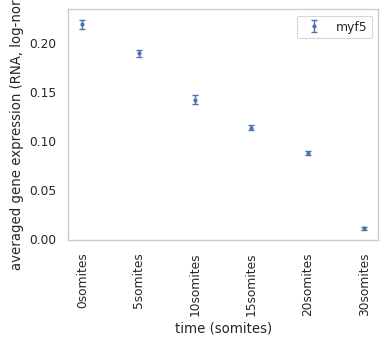

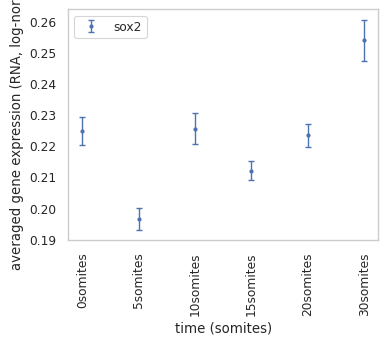

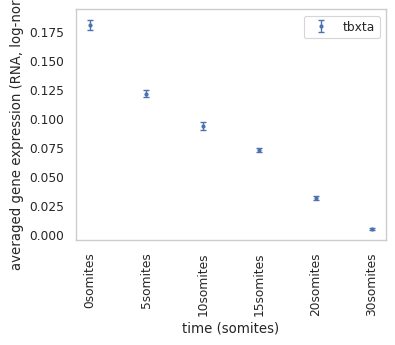

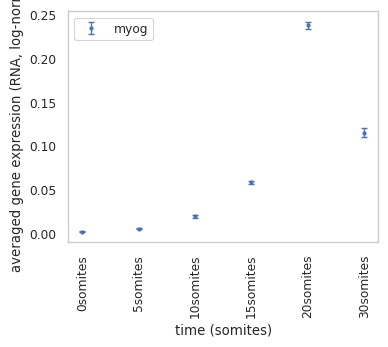

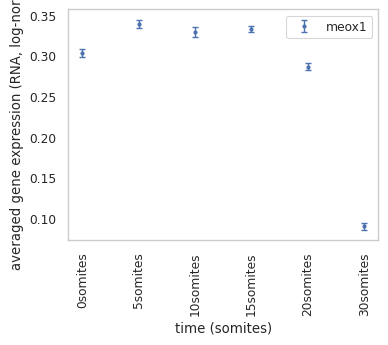

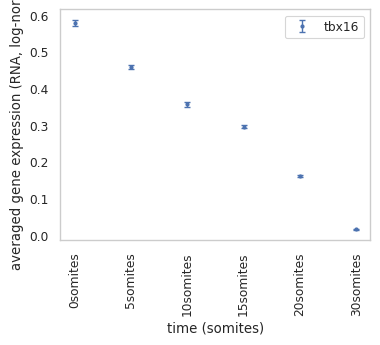

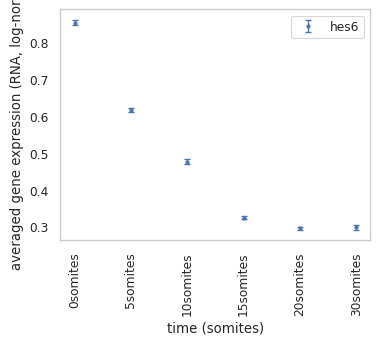

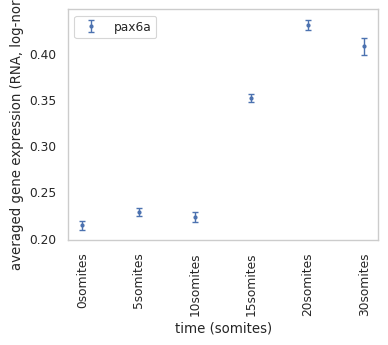

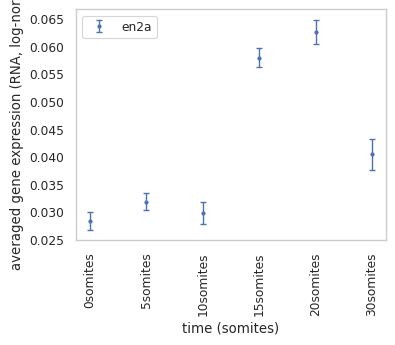

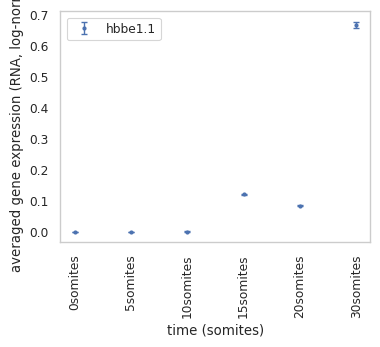

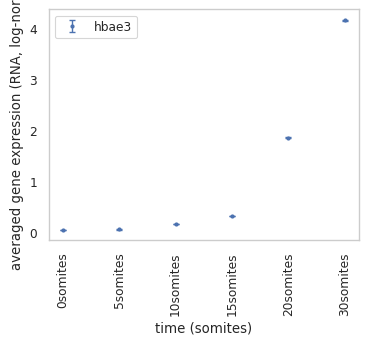

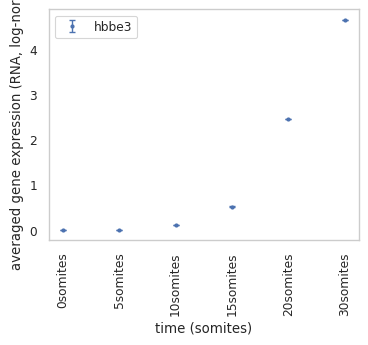

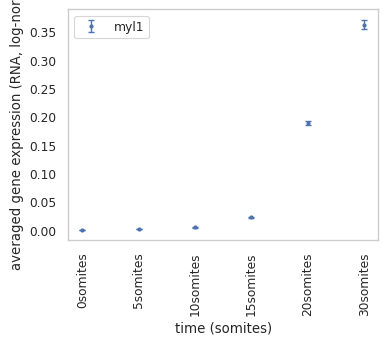

In [289]:
for gene in list_genes:
    # generate a plot
    plt.figure(figsize=(4, 3))
    plt.errorbar(timepoints_by_genes_sorted.index, 
                 timepoints_by_genes_sorted[gene], 
                 timepoints_by_genes_sem_sorted[gene],
                 fmt='o', capsize=2, linestyle='None', 
                 label=gene, markersize=2, elinewidth=1, capthick=1)
    # plt.title('Scatter Plot of log-normalized counts over Timepoints')
    plt.xlabel('time (somites)')
    plt.ylabel('averaged gene expression (RNA, log-norm)')
    plt.xticks(timepoints_by_genes_sorted.index)  # Show original timepoint labels
    plt.xticks(rotation=90)
    plt.legend()
    plt.grid(False)
    plt.savefig(figpath + f"RNA_timepoints_{gene}.pdf")
    plt.show()

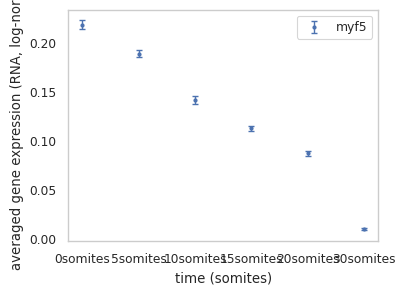

In [39]:
# Plotting the gene.activity dynamics (0-30 somites)
# define the gene
gene = "myf5"

# generate a plot
plt.figure(figsize=(4, 3))
plt.errorbar(timepoints_by_genes_sorted.index, 
             timepoints_by_genes_sorted[gene], 
             timepoints_by_genes_sem_sorted[gene],
             fmt='o', capsize=2, linestyle='None', 
             label=gene, markersize=2, elinewidth=1, capthick=1)
# plt.title('Scatter Plot of log-normalized counts over Timepoints')
plt.xlabel('time (somites)')
plt.ylabel('averaged gene expression (RNA, log-norm)')
plt.xticks(timepoints_by_genes_sorted.index)  # Show original timepoint labels
plt.legend()
plt.grid(False)
# plt.savefig(figpath + "gene_activity_score_myf5.pdf")
plt.show()

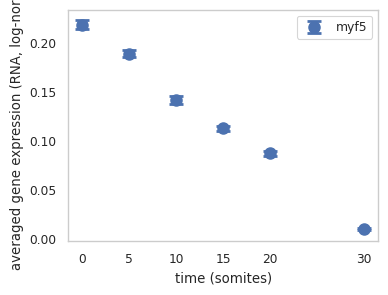

In [46]:
# # Plotting the gene.activity dynamics (0-30 somites)
# # define the gene
# gene = "myf5"

# # generate a plot
# plt.figure(figsize=(4, 3))
# plt.errorbar([0, 5, 10, 15, 20, 30], 
#              timepoints_by_genes_sorted[gene], 
#              timepoints_by_genes_sem_sorted[gene],
#              fmt='o', capsize=5, linestyle='None', 
#              label=gene, markersize=8, elinewidth=2, capthick=2)
# # plt.title('Scatter Plot of log-normalized counts over Timepoints')
# plt.xlabel('time (somites)')
# plt.ylabel('averaged gene expression (RNA, log-norm)')
# # plt.xticks(timepoints_by_genes_sorted.index)  # Show original timepoint labels
# plt.xticks([0, 5, 10, 15, 20, 30])
# plt.legend()
# plt.grid(False)
# plt.savefig(figpath + "RNA_timepoints_myf5.pdf")
# plt.show()

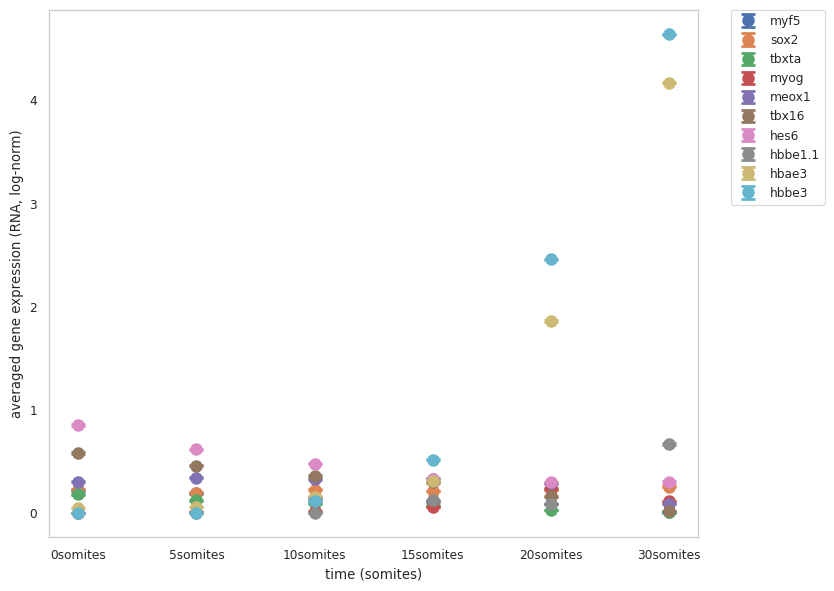

In [58]:
# Plotting the gene.activity dynamics (0-30 somites)
# define the gene
list_genes = ["myf5","sox2","tbxta","myog",
              "meox1","tbx16","hes6",
              "hbbe1.1","hbae3","hbbe3"]

# generate a plot
plt.figure(figsize=(10, 6))

for gene in list_genes:
    plt.errorbar(timepoints_by_genes_sorted.index, 
                 timepoints_by_genes_sorted[gene], 
                 timepoints_by_genes_sem_sorted[gene],
                 fmt='o', capsize=5, linestyle='None', 
                 label=gene, markersize=8, elinewidth=2, capthick=2)
    
# plt.title('Scatter Plot of log-normalized counts over Timepoints')
plt.xlabel('time (somites)')
plt.ylabel('averaged gene expression (RNA, log-norm)')
plt.xticks(timepoints_by_genes_sorted.index)  # Show original timepoint labels
# Move the legend outside of the plot to the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust the rect parameter to make room for the legend
plt.grid(False)
# plt.savefig(figpath + "RNA_timepoints_genesets.pdf")
plt.show()

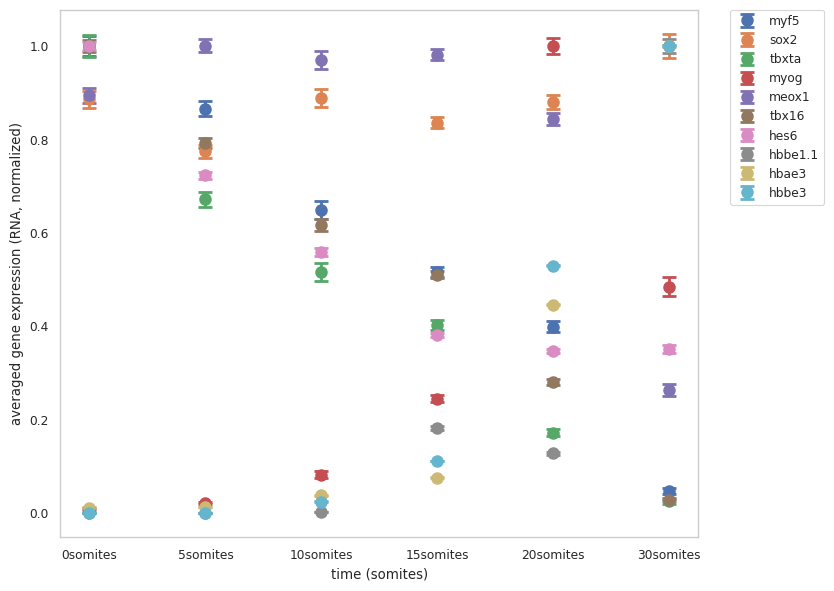

In [59]:
# Plotting the gene.activity dynamics (0-30 somites)
# define the gene
list_genes = ["myf5","sox2","tbxta","myog",
              "meox1","tbx16","hes6",
              "hbbe1.1","hbae3","hbbe3"]

# generate a plot
plt.figure(figsize=(10, 6))

for gene in list_genes:
    # Normalization step: divide by the max value to scale to 1
    normalized_values = timepoints_by_genes_sorted[gene] / timepoints_by_genes_sorted[gene].max()
    plt.errorbar(timepoints_by_genes_sorted.index, 
                 normalized_values, 
                 yerr=timepoints_by_genes_sem_sorted[gene] / timepoints_by_genes_sorted[gene].max(), 
                 fmt='o', capsize=5, linestyle='None', 
                 label=gene, markersize=8, elinewidth=2, capthick=2)
    
# plt.title('Scatter Plot of log-normalized counts over Timepoints')
plt.xlabel('time (somites)')
plt.ylabel('averaged gene expression (RNA, normalized)')
plt.xticks(timepoints_by_genes_sorted.index)  # Show original timepoint labels
# Move the legend outside of the plot to the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust the rect parameter to make room for the legend
plt.grid(False)
# plt.savefig(figpath + "gene_activity_score_genesets_normalized.pdf")
plt.show()

## Step 2. ATAC dynamics using cells-by-gene.activity (Signac)

- The gene.activity scores were computed by Signac for individual timepoints  (**using the "peaks_merged" for individual timepoints**, not "peaks_integrated" after the merge/integration over timepoints)
- We created a concatenated adata (all cells-by-gene.activity, with adata.obs having "dataset" identifiers)


### averaged gene.activity dynamics along the real time

In [290]:
# genes_to_plot = ['tbxta', 'sox2', 'myf5', 'pax6a', 'meox1']
# define the gene
list_genes = ["myf5","sox2","tbxta","myog",
              "meox1","tbx16","hes6",'pax6a',"en2a",
              "hbbe1.1","hbae3","hbbe3","myl1"]

In [309]:
# subset the adata_RNA for the list of genes (this is to reduce the computing resource/time)
adata_ATAC_sub = adata_ATAC[:, adata_ATAC.var_names.isin(list_genes)]
adata_ATAC_sub

View of AnnData object with n_obs × n_vars = 94562 × 13
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'Pseudotime', 'Lineage_Meso', 'Lineage_NeuroEcto', 'Pseudotime_Lineage_Meso', 'Pseudotime_Lineage_NeuroEcto', 'annotation_ML_coarse'
    var: 'features'
    obsm: 'X_umap', 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'

In [310]:
# create a dataframe of cells-by-gene.activity (Signac)
count_matrice_atac = pd.DataFrame(adata_ATAC_sub.X.todense(),
                             index=adata_ATAC_sub.obs.index,
                             columns=adata_ATAC_sub.var_names)
count_matrice_atac.head()

,myf5,en2a,hbbe1.1,hbae3,hes6,myl1,tbx16,hbbe3,meox1,tbxta,myog,sox2,pax6a
AAACAGCCACCTAAGC-1_1,0.000000,0.961459,0.0,0.0,0.961459,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.961459
AAACAGCCAGGGAGGA-1_1,0.000000,0.000000,0.0,0.0,0.961259,0.0,0.0,0.0,0.0,1.765580,0.00000,0.000000,0.000000
AAACAGCCATAGACCC-1_1,0.000000,0.324538,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.324538,0.56916,0.569160,1.194028
AAACATGCAAACTCAT-1_1,0.615839,0.000000,0.0,0.0,0.994147,0.0,0.0,0.0,0.0,0.615839,0.00000,0.000000,2.055363
AAACATGCAAGGACCA-1_1,1.450889,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.00000,1.450889,0.000000


In [311]:
# transfer the "dataset" category labels to count_matrice df
count_matrice_atac["dataset"] = adata_ATAC_sub.obs["dataset"]
count_matrice_atac["annotation_ML_coarse"] = adata_RNA_sub.obs["annotation_ML_coarse"]
count_matrice_atac["dev_stage"] = adata_RNA_sub.obs["dev_stage"]

In [312]:
# add the "timepoints" category for the column

# define the dictionary for mapping
dict_timepoints = {"TDR126":"0somites",
                   "TDR127":"5somites",
                   "TDR128":"10somites",
                   "TDR118":"15somites",
                   "TDR119":"15somites",
                   "TDR125":"20somites",
                   "TDR124":"30somites"}

# map the "dataset" to "timepoints"
count_matrice_atac["timepoints"] = count_matrice_atac["dataset"].map(dict_timepoints)
count_matrice_atac.head()

,myf5,en2a,hbbe1.1,hbae3,hes6,myl1,tbx16,hbbe3,meox1,tbxta,myog,sox2,pax6a,dataset,annotation_ML_coarse,dev_stage,timepoints
AAACAGCCACCTAAGC-1_1,0.000000,0.961459,0.0,0.0,0.961459,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.961459,TDR118,epidermis,15somites,15somites
AAACAGCCAGGGAGGA-1_1,0.000000,0.000000,0.0,0.0,0.961259,0.0,0.0,0.0,0.0,1.765580,0.00000,0.000000,0.000000,TDR118,pronephros,15somites,15somites
AAACAGCCATAGACCC-1_1,0.000000,0.324538,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.324538,0.56916,0.569160,1.194028,TDR118,hindbrain,15somites,15somites
AAACATGCAAACTCAT-1_1,0.615839,0.000000,0.0,0.0,0.994147,0.0,0.0,0.0,0.0,0.615839,0.00000,0.000000,2.055363,TDR118,spinal_cord,15somites,15somites
AAACATGCAAGGACCA-1_1,1.450889,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.00000,1.450889,0.000000,TDR118,neural_optic,15somites,15somites


In [313]:
# compute the averaged gene expression

# Define numeric columns (gene expression columns) by selecting columns with float/int data types
numeric_columns = count_matrice_atac.select_dtypes(include=[np.number]).columns.tolist()

# Compute the mean gene expression level across all cells per 'timepoints'
timepoints_by_gene_activity = count_matrice_atac.groupby('timepoints')[numeric_columns].mean()

# Display the result
print(timepoints_by_gene_activity)

                myf5      en2a   hbbe1.1     hbae3      hes6      myl1  \
timepoints                                                               
0somites    0.150669  0.422694  0.057264  0.077749  0.673622  0.060671   
10somites   0.107037  0.402454  0.060622  0.071561  0.610919  0.067076   
15somites   0.085147  0.329130  0.057990  0.048599  0.523513  0.071766   
20somites   0.068044  0.428949  0.063589  0.070169  0.609352  0.109006   
30somites   0.028137  0.291960  0.037687  0.044405  0.564202  0.079989   
5somites    0.127749  0.377536  0.051858  0.065586  0.626274  0.063315   

               tbx16     hbbe3     meox1     tbxta      myog      sox2  \
timepoints                                                               
0somites    0.305945  0.022161  0.220620  0.214374  0.054883  0.393299   
10somites   0.186992  0.027405  0.224874  0.169638  0.079046  0.372621   
15somites   0.142111  0.019639  0.184445  0.131153  0.097341  0.350204   
20somites   0.105859  0.025714  0.206

In [314]:
# compute the "standard errors" gene.activity across all cells per "timepoint" (TDR118 and TDR119 will be merged here)
timepoints_by_gene_activity_sem = count_matrice_atac.groupby('timepoints')[numeric_columns].sem()
timepoints_by_gene_activity_sem.head()


,myf5,en2a,hbbe1.1,hbae3,hes6,myl1,tbx16,hbbe3,meox1,tbxta,myog,sox2,pax6a
timepoints,,,,,,,,,,,,,
0somites,0.002590,0.003261,0.001383,0.001613,0.003795,0.001423,0.003492,0.000884,0.002788,0.002552,0.001413,0.003243,0.004313
10somites,0.002563,0.003898,0.001655,0.001813,0.004539,0.001853,0.003350,0.001156,0.003381,0.002728,0.002207,0.003839,0.005428
15somites,0.001661,0.002782,0.001252,0.001148,0.003323,0.001427,0.002102,0.000761,0.002255,0.001865,0.001760,0.002863,0.004067
20somites,0.001550,0.002893,0.001270,0.001360,0.003185,0.001828,0.001828,0.000925,0.002386,0.001874,0.002214,0.002949,0.004283
30somites,0.001909,0.005612,0.002175,0.002406,0.007058,0.003146,0.002620,0.002128,0.004280,0.003074,0.003190,0.006826,0.009415


In [315]:
# numeric_timepoints to re-order the rows (timepoints_by_genes)
timepoints_by_gene_activity['numeric_timepoints'] = timepoints_by_gene_activity.index.str.extract('(\d+)').astype(int).values
timepoints_by_gene_activity['numeric_timepoints']

# Sort by the numeric timepoints to ensure correct order in plot
timepoints_by_gene_activity_sorted = timepoints_by_gene_activity.sort_values('numeric_timepoints')
timepoints_by_gene_activity_sorted

,myf5,en2a,hbbe1.1,hbae3,hes6,myl1,tbx16,hbbe3,meox1,tbxta,myog,sox2,pax6a,numeric_timepoints
timepoints,,,,,,,,,,,,,,
0somites,0.150669,0.422694,0.057264,0.077749,0.673622,0.060671,0.305945,0.022161,0.220620,0.214374,0.054883,0.393299,0.746641,0
5somites,0.127749,0.377536,0.051858,0.065586,0.626274,0.063315,0.249068,0.021611,0.221500,0.179289,0.075625,0.350233,0.738299,5
10somites,0.107037,0.402454,0.060622,0.071561,0.610919,0.067076,0.186992,0.027405,0.224874,0.169638,0.079046,0.372621,0.728548,10
15somites,0.085147,0.329130,0.057990,0.048599,0.523513,0.071766,0.142111,0.019639,0.184445,0.131153,0.097341,0.350204,0.700688,15
20somites,0.068044,0.428949,0.063589,0.070169,0.609352,0.109006,0.105859,0.025714,0.206480,0.141640,0.123802,0.436428,0.867264,20
30somites,0.028137,0.291960,0.037687,0.044405,0.564202,0.079989,0.054540,0.029988,0.143327,0.077707,0.072787,0.470039,0.923381,30


In [316]:
# numeric_timepoints to re-order the rows (timepoints_by_genes_sem)
timepoints_by_gene_activity_sem['numeric_timepoints'] = timepoints_by_gene_activity_sem.index.str.extract('(\d+)').astype(int).values
timepoints_by_gene_activity_sem['numeric_timepoints']

# Sort by the numeric timepoints to ensure correct order in plot
timepoints_by_gene_activity_sem_sorted = timepoints_by_gene_activity_sem.sort_values('numeric_timepoints')
timepoints_by_gene_activity_sem_sorted

,myf5,en2a,hbbe1.1,hbae3,hes6,myl1,tbx16,hbbe3,meox1,tbxta,myog,sox2,pax6a,numeric_timepoints
timepoints,,,,,,,,,,,,,,
0somites,0.002590,0.003261,0.001383,0.001613,0.003795,0.001423,0.003492,0.000884,0.002788,0.002552,0.001413,0.003243,0.004313,0
5somites,0.002101,0.002833,0.001172,0.001295,0.003345,0.001309,0.002791,0.000767,0.002469,0.002100,0.001515,0.002794,0.003911,5
10somites,0.002563,0.003898,0.001655,0.001813,0.004539,0.001853,0.003350,0.001156,0.003381,0.002728,0.002207,0.003839,0.005428,10
15somites,0.001661,0.002782,0.001252,0.001148,0.003323,0.001427,0.002102,0.000761,0.002255,0.001865,0.001760,0.002863,0.004067,15
20somites,0.001550,0.002893,0.001270,0.001360,0.003185,0.001828,0.001828,0.000925,0.002386,0.001874,0.002214,0.002949,0.004283,20
30somites,0.001909,0.005612,0.002175,0.002406,0.007058,0.003146,0.002620,0.002128,0.004280,0.003074,0.003190,0.006826,0.009415,30


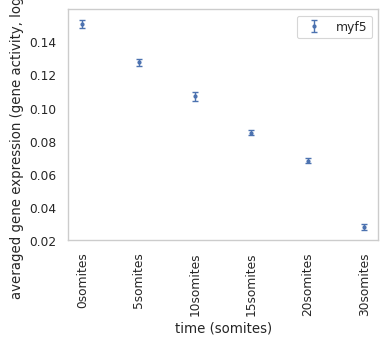

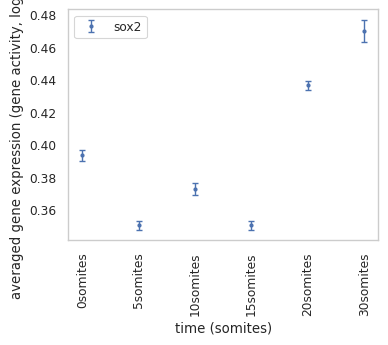

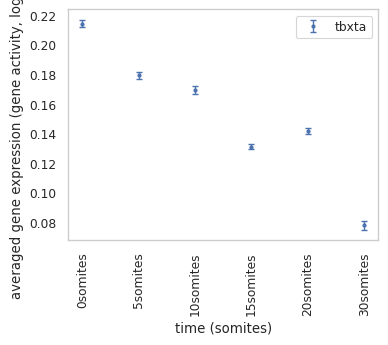

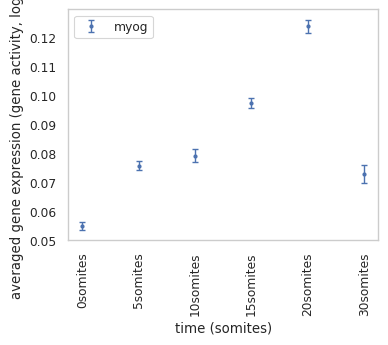

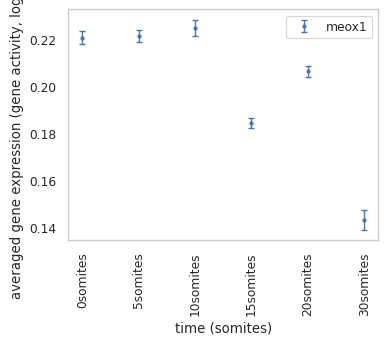

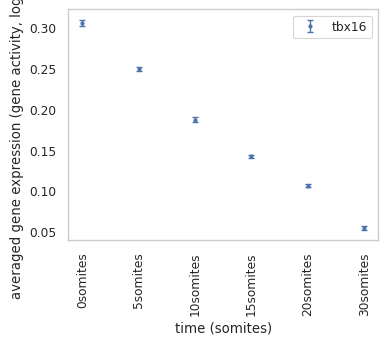

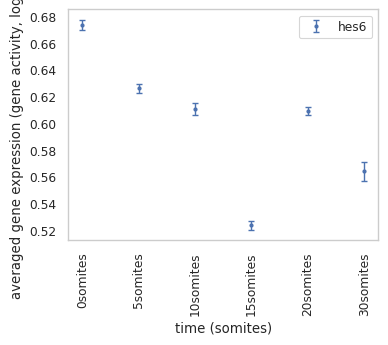

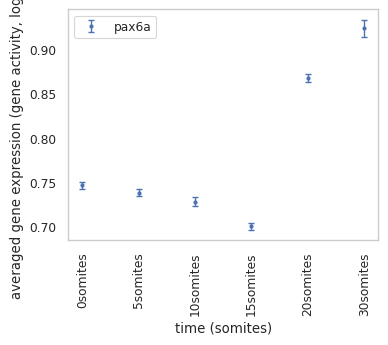

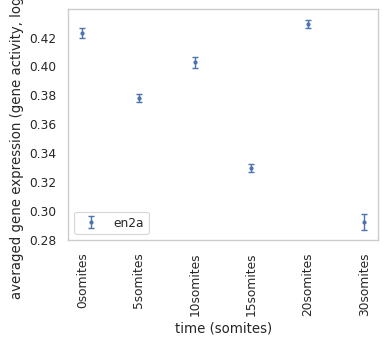

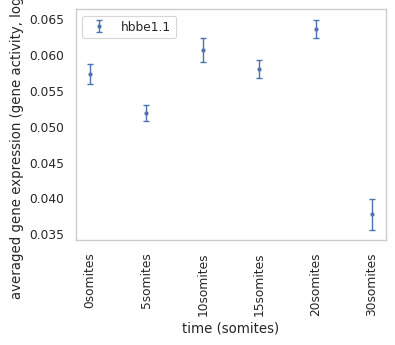

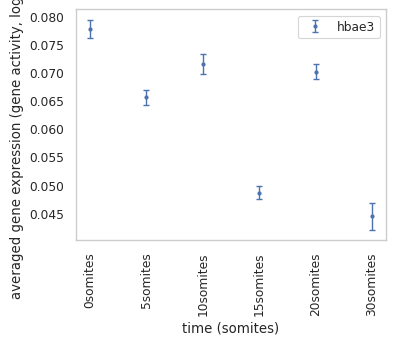

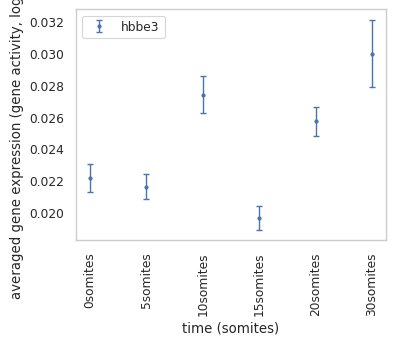

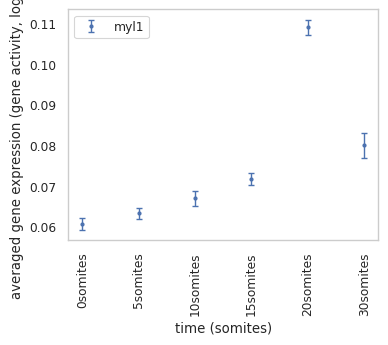

In [318]:
for gene in list_genes:
    # generate a plot
    plt.figure(figsize=(4, 3))
    plt.errorbar(timepoints_by_gene_activity_sorted.index, 
                 timepoints_by_gene_activity_sorted[gene], 
                 timepoints_by_gene_activity_sem_sorted[gene],
                 fmt='o', capsize=2, linestyle='None', 
                 label=gene, markersize=2, elinewidth=1, capthick=1)
    # plt.title('Scatter Plot of log-normalized counts over Timepoints')
    plt.xlabel('time (somites)')
    plt.ylabel('averaged gene expression (gene activity, log-norm)')
    plt.xticks(timepoints_by_genes_sorted.index)  # Show original timepoint labels
    plt.xticks(rotation=90)
    plt.legend()
    plt.grid(False)
    plt.savefig(figpath + f"ATAC_timepoints_{gene}.pdf")
    plt.show()

## Step 3. visualization

- plotting the RNA and ATAC (gene.activity) in the same scatter plot (for each gene)

- plotting the correlation between RNA and ATAC (gene.activity) for each gene (color the dots with the viridis color palette for timepoints).

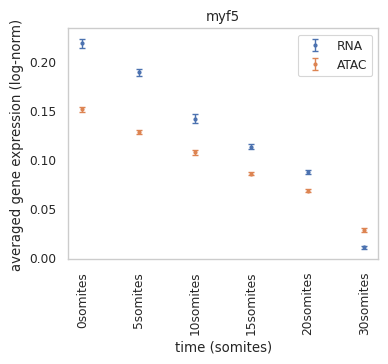

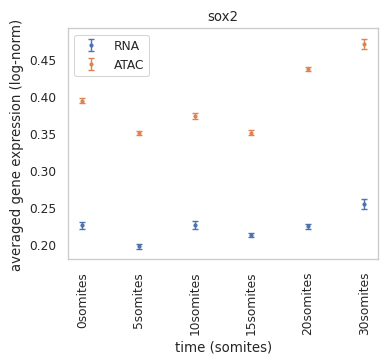

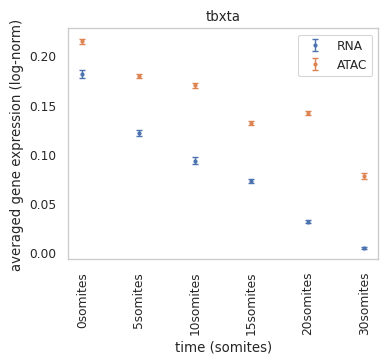

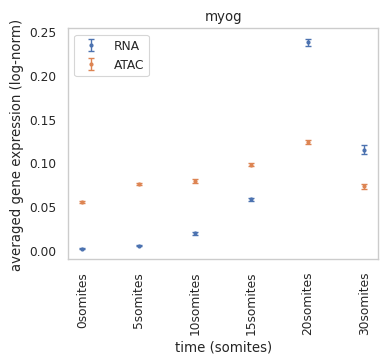

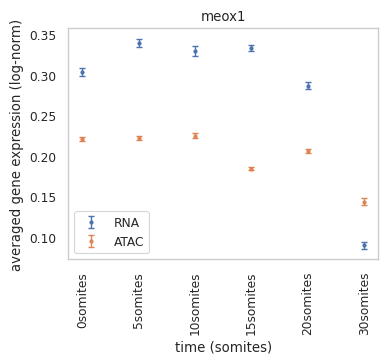

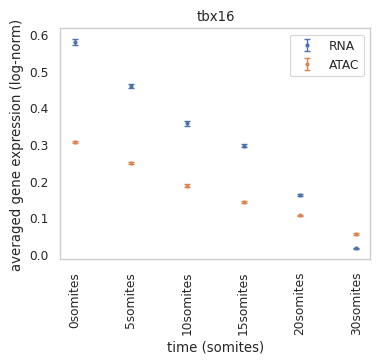

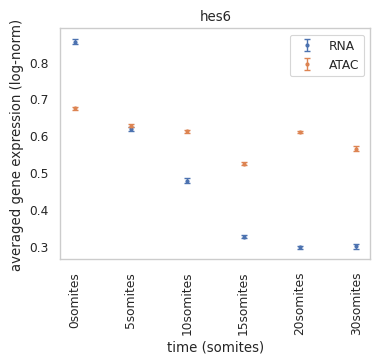

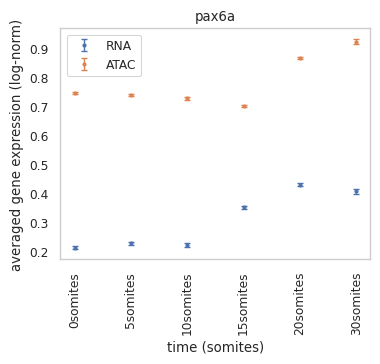

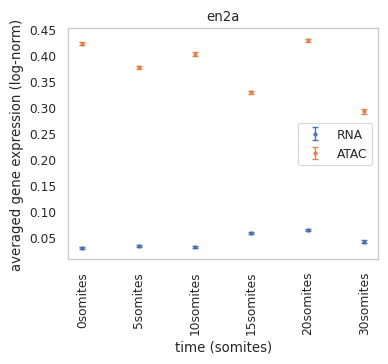

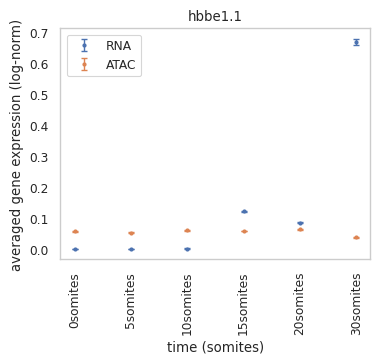

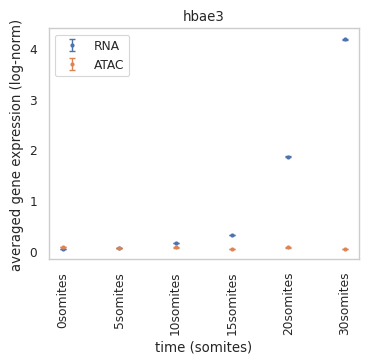

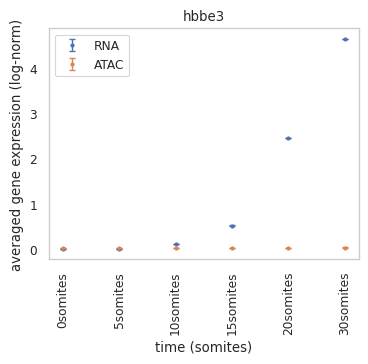

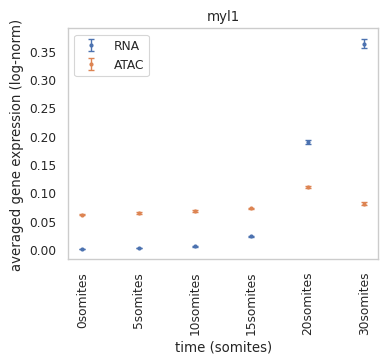

In [322]:
for gene in list_genes:
    # generate a plot
    plt.figure(figsize=(4, 3))
    plt.errorbar(timepoints_by_genes_sorted.index, 
                 timepoints_by_genes_sorted[gene], 
                 timepoints_by_genes_sem_sorted[gene],
                 fmt='o', capsize=2, linestyle='None', 
                 label=gene, markersize=2, elinewidth=1, capthick=1)
    plt.errorbar(timepoints_by_gene_activity_sorted.index, 
                 timepoints_by_gene_activity_sorted[gene], 
                 timepoints_by_gene_activity_sem_sorted[gene],
                 fmt='o', capsize=2, linestyle='None', 
                 label=gene, markersize=2, elinewidth=1, capthick=1)
    plt.title(f'{gene}')
    plt.xlabel('time (somites)')
    plt.ylabel('averaged gene expression (log-norm)')
    plt.xticks(timepoints_by_genes_sorted.index)  # Show original timepoint labels
    plt.xticks(rotation=90)
    plt.legend(["RNA", "ATAC"])
    plt.grid(False)
    plt.savefig(figpath + f"RNA_ATAC_timepoints_{gene}.pdf")
    plt.show()

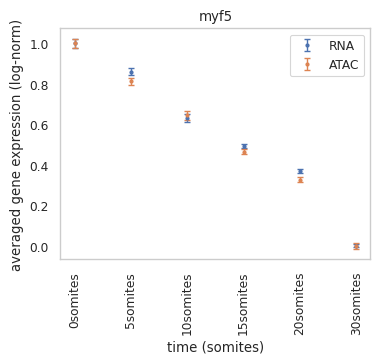

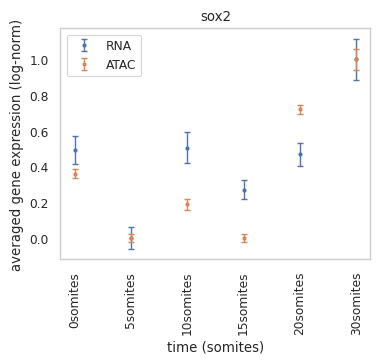

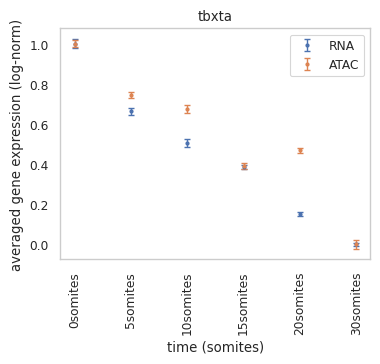

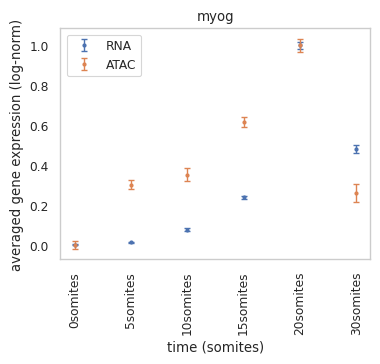

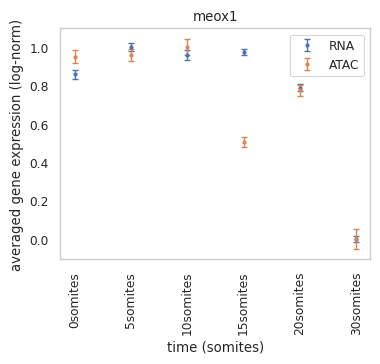

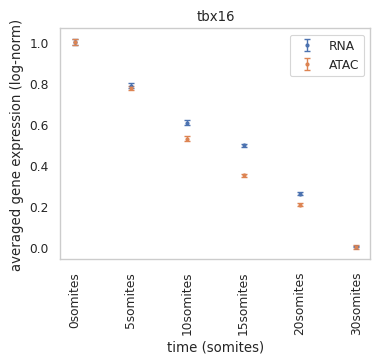

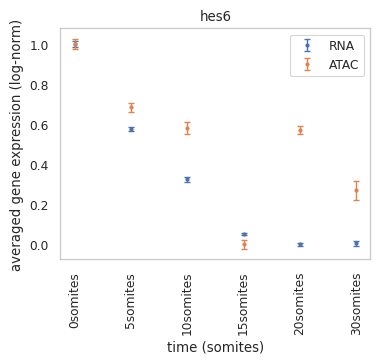

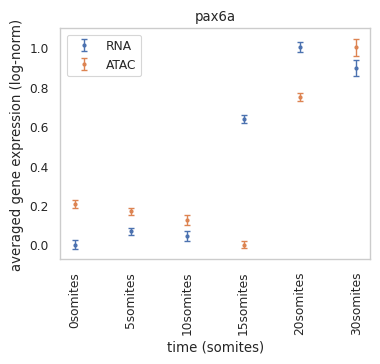

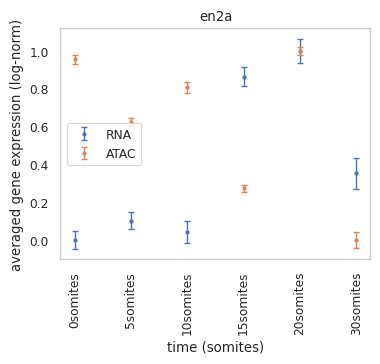

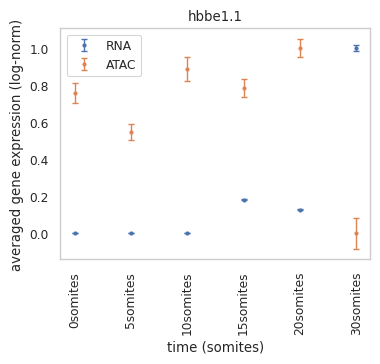

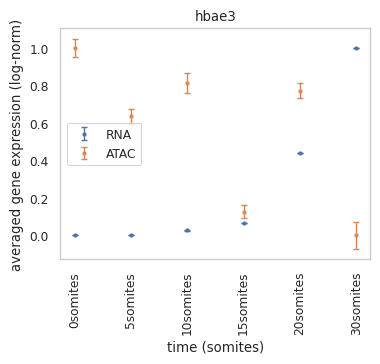

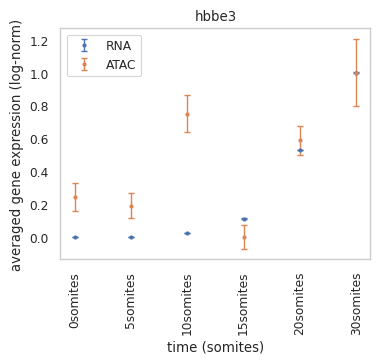

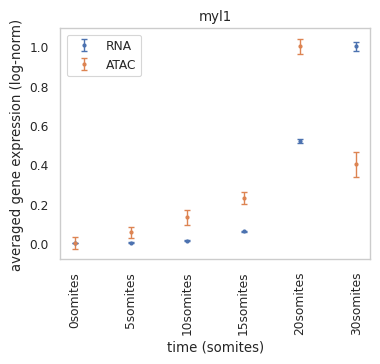

In [354]:
# Just to monitor the trend over time, we can normalize each modality

def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

for gene in list_genes:
    
#     # normalize the RNA
#     max_rna = np.max(timepoints_by_genes_sorted[gene])
#     rna_norm = timepoints_by_genes_sorted[gene]/max_rna
#     rna_sem_norm = timepoints_by_genes_sem_sorted[gene]/max_rna
    
#     # normalize the ATAC
#     max_atac = np.max(timepoints_by_gene_activity_sorted[gene])
#     atac_norm = timepoints_by_gene_activity_sorted[gene]/max_atac
#     atac_sem_norm = timepoints_by_gene_activity_sem_sorted[gene]/max_atac
    rna_norm = normalize(timepoints_by_genes_sorted[gene])
    rna_sem_norm = timepoints_by_genes_sem_sorted[gene] / (timepoints_by_genes_sorted[gene].max() - timepoints_by_genes_sorted[gene].min())
    atac_norm = normalize(timepoints_by_gene_activity_sorted[gene])
    atac_sem_norm = timepoints_by_gene_activity_sem_sorted[gene] / (timepoints_by_gene_activity_sorted[gene].max() - timepoints_by_gene_activity_sorted[gene].min())


    
    # generate a plot
    plt.figure(figsize=(4, 3))
    plt.errorbar(timepoints_by_genes_sorted.index, 
                 rna_norm, 
                 rna_sem_norm,
                 fmt='o', capsize=2, linestyle='None', 
                 label=gene, markersize=2, elinewidth=1, capthick=1)
    plt.errorbar(timepoints_by_gene_activity_sorted.index, 
                 atac_norm, 
                 atac_sem_norm,
                 fmt='o', capsize=2, linestyle='None', 
                 label=gene, markersize=2, elinewidth=1, capthick=1)
    plt.title(f'{gene}')
    plt.xlabel('time (somites)')
    plt.ylabel('averaged gene expression (log-norm)')
    plt.xticks(timepoints_by_genes_sorted.index)  # Show original timepoint labels
    plt.xticks(rotation=90)
    plt.legend(["RNA", "ATAC"])
    plt.grid(False)
    plt.savefig(figpath + f"RNA_ATAC_timepoints_{gene}_norm.pdf")
    plt.show()

### correlation between RNA and ATAC

In [329]:
color_dict

timepoints_by_gene_activity_sorted.index.map(color_dict)

Index(['#C6DBEF', '#6785AD', '#B3C9E1', '#A0B8D4', '#8DA7C7', '#7A96BA'], dtype='object', name='timepoints')

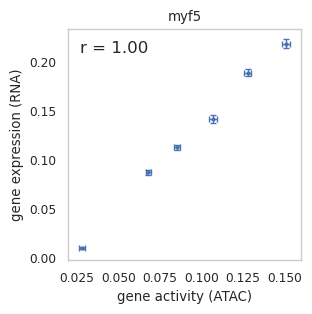

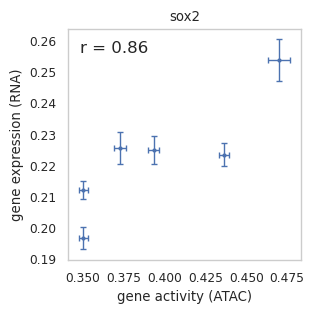

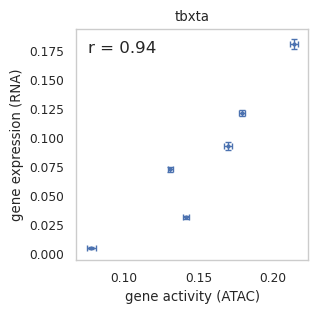

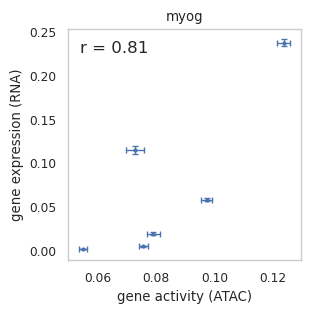

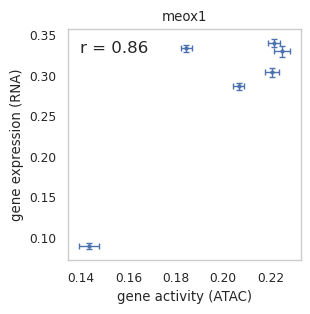

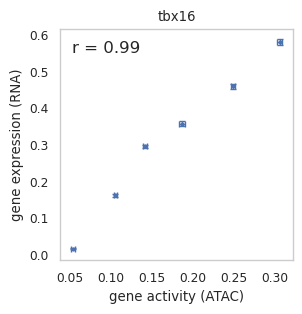

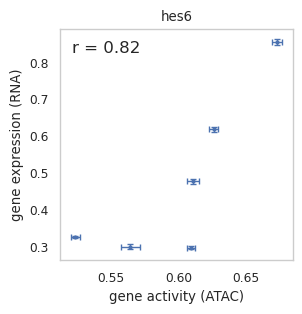

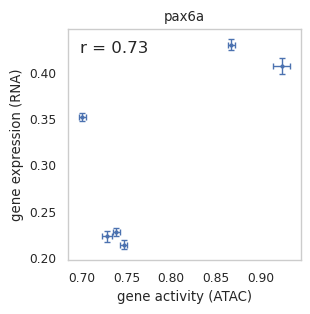

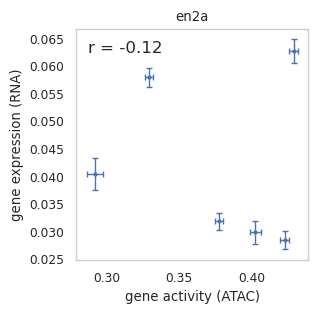

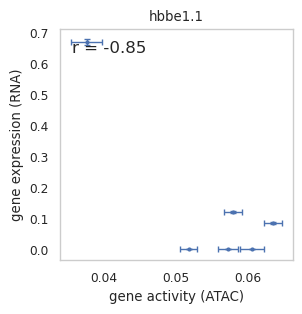

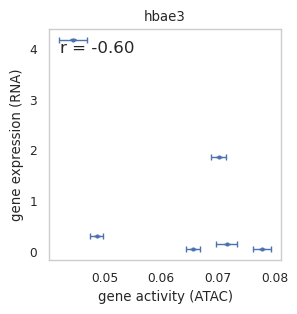

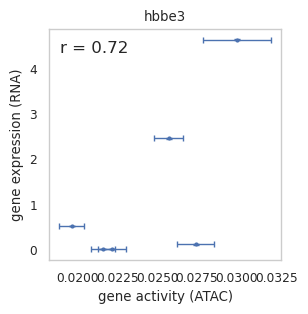

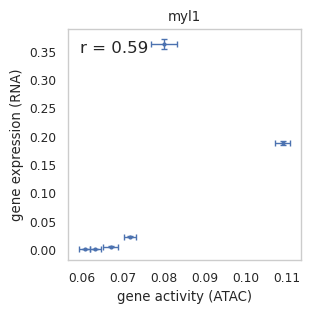

In [355]:
from scipy.stats import pearsonr

# plot the correlation between RNA and ATAC
for gene in list_genes:
    
    # define the color palette using the viridis
    colors = timepoints_by_gene_activity_sorted.index.map(color_dict)
    
    # define the x_vals and y_vals
    # Collect data points for correlation calculation
    x_vals = timepoints_by_gene_activity_sorted[gene]
    y_vals = timepoints_by_genes_sorted[gene]
    
    # Calculate correlation coefficient
    correlation, _ = pearsonr(x_vals, y_vals)
    
    # generate a plot
    plt.figure(figsize=(3, 3))
    plt.errorbar(x = timepoints_by_gene_activity_sorted[gene],
                 y = timepoints_by_genes_sorted[gene],
                 xerr=timepoints_by_gene_activity_sem_sorted[gene],
                 yerr=timepoints_by_genes_sem_sorted[gene],
                 fmt='o', capsize=2, linestyle='None', 
                 label=gene, markersize=2, elinewidth=1, capthick=1,)
                 # ecolor=colors, color=colors)
        
    # Add the correlation coefficient text to the plot
    plt.text(0.05, 0.95, f'r = {correlation:.2f}', transform=plt.gca().transAxes,
             fontsize=12, verticalalignment='top')

    plt.title(f'{gene}')
    plt.xlabel('gene activity (ATAC)')
    plt.ylabel('gene expression (RNA)')
    # plt.xticks(timepoints_by_genes_sorted.index)  # Show original timepoint labels
    # plt.xticks(rotation=90)
    # plt.legend(["RNA", "ATAC"])
    plt.grid(False)
    plt.savefig(figpath + f"RNA_ATAC_corr_scatter_{gene}.pdf")
    plt.show()

## [HOLD] Step 3 . Find patterns in the RNA/ATAC dynamics (real-time)

- First, we will normalize the timepoints_by_genes dataframe for each gene's maximum gene.activity score (averaged)
- Second, we will generate a heatmap for genes-by-timepoints
- Lastly, we will perform hirarchical clustering on the heatmap to find the gene clusters that have similar ATAC dynamics (either increasing or decreasing over time).

In [98]:
# first, exclude the "numeric_timepoints" column before normalization
timepoints_by_genes_sorted.drop('numeric_timepoints', axis=1, inplace=True)

# Normalize each gene's expression levels to the maximum value for that gene
normalized_timepoints_by_genes = timepoints_by_genes_sorted.divide(timepoints_by_genes_sorted.max())
normalized_timepoints_by_genes.head()

,ptpn12,phtf2,phtf2.1,CU856344.1,si:zfos-932h1.3,mansc1,lrp6,dusp16,crebl2,gpr19,...,mt-co2,mt-atp8,mt-atp6,mt-co3,mt-nd3,mt-nd4l,mt-nd4,mt-nd5,mt-nd6,mt-cyb
timepoints,,,,,,,,,,,,,,,,,,,,,
0somites,0.925299,1.000000,1.000000,1.000000,1.000000,0.978833,0.996614,1.000000,1.000000,1.000000,...,0.797623,0.789397,0.797632,0.799873,0.792083,0.791100,0.809720,0.818155,0.786721,0.812451
5somites,0.971938,0.908025,0.902015,0.963170,0.921151,1.000000,1.000000,0.865590,0.803913,0.593862,...,0.907791,0.905362,0.908750,0.908745,0.902663,0.902585,0.913697,0.922762,0.911524,0.922297
10somites,1.000000,0.835346,0.824294,0.842048,0.855967,0.825859,0.920787,0.791133,0.762057,0.507760,...,0.787032,0.777368,0.785998,0.787762,0.777611,0.777604,0.797965,0.807474,0.773057,0.799399
15somites,0.794314,0.747085,0.779239,0.733673,0.720805,0.829988,0.763962,0.646208,0.604143,0.233134,...,0.779796,0.767294,0.780020,0.783846,0.778495,0.776929,0.793618,0.794752,0.750797,0.783483
20somites,0.852545,0.921242,0.966473,0.807666,0.896432,0.834767,0.911061,0.794453,0.810207,0.519330,...,0.835100,0.830015,0.836330,0.836516,0.827984,0.825594,0.838696,0.842373,0.816236,0.835613


In [116]:
# Replace any infinite values with NaN
timepoints_by_genes_sorted.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop any rows or columns with NaN values if they can't be imputed
# normalized_timepoints_by_genes.dropna(axis=0, inplace=True)  # Drop rows with NaN
timepoints_by_genes_sorted.dropna(axis=1, inplace=True)  # Drop columns with NaN

In [104]:
# Replace any infinite values with NaN
normalized_timepoints_by_genes.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop any rows or columns with NaN values if they can't be imputed
# normalized_timepoints_by_genes.dropna(axis=0, inplace=True)  # Drop rows with NaN
normalized_timepoints_by_genes.dropna(axis=1, inplace=True)  # Drop columns with NaN

In [107]:
normalized_timepoints_by_genes.T.head()

timepoints,0somites,5somites,10somites,15somites,20somites,30somites
ptpn12,0.925299,0.971938,1.000000,0.794314,0.852545,0.612921
phtf2,1.000000,0.908025,0.835346,0.747085,0.921242,0.581688
phtf2.1,1.000000,0.902015,0.824294,0.779239,0.966473,0.660974
CU856344.1,1.000000,0.963170,0.842048,0.733673,0.807666,0.563938
si:zfos-932h1.3,1.000000,0.921151,0.855967,0.720805,0.896432,0.831884


<Figure size 1200x800 with 0 Axes>

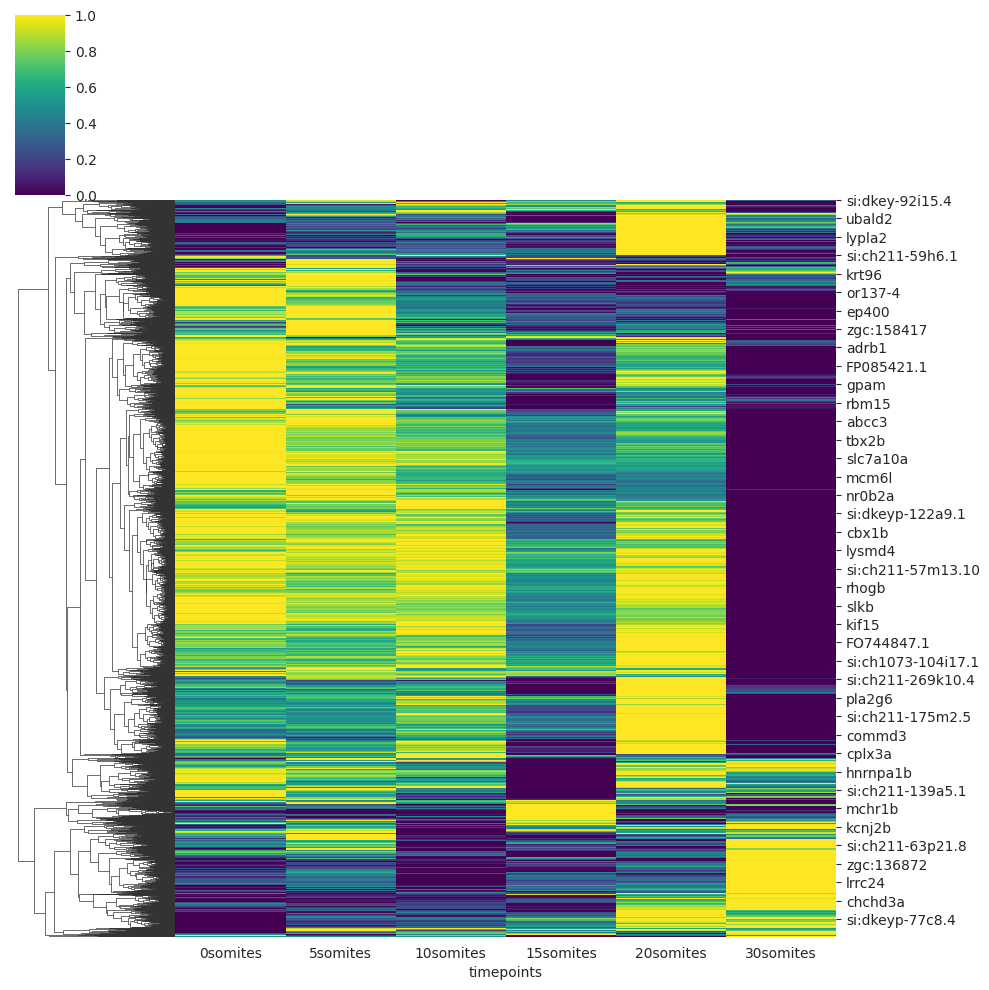

In [113]:
# Create a heatmap with hierarchical clustering
plt.figure(figsize=(12, 8))
sns.clustermap(normalized_timepoints_by_genes.T, method='average', metric='euclidean', cmap='viridis', standard_scale=0,
               row_cluster=True, col_cluster=False)
plt.show()

<Figure size 1200x800 with 0 Axes>

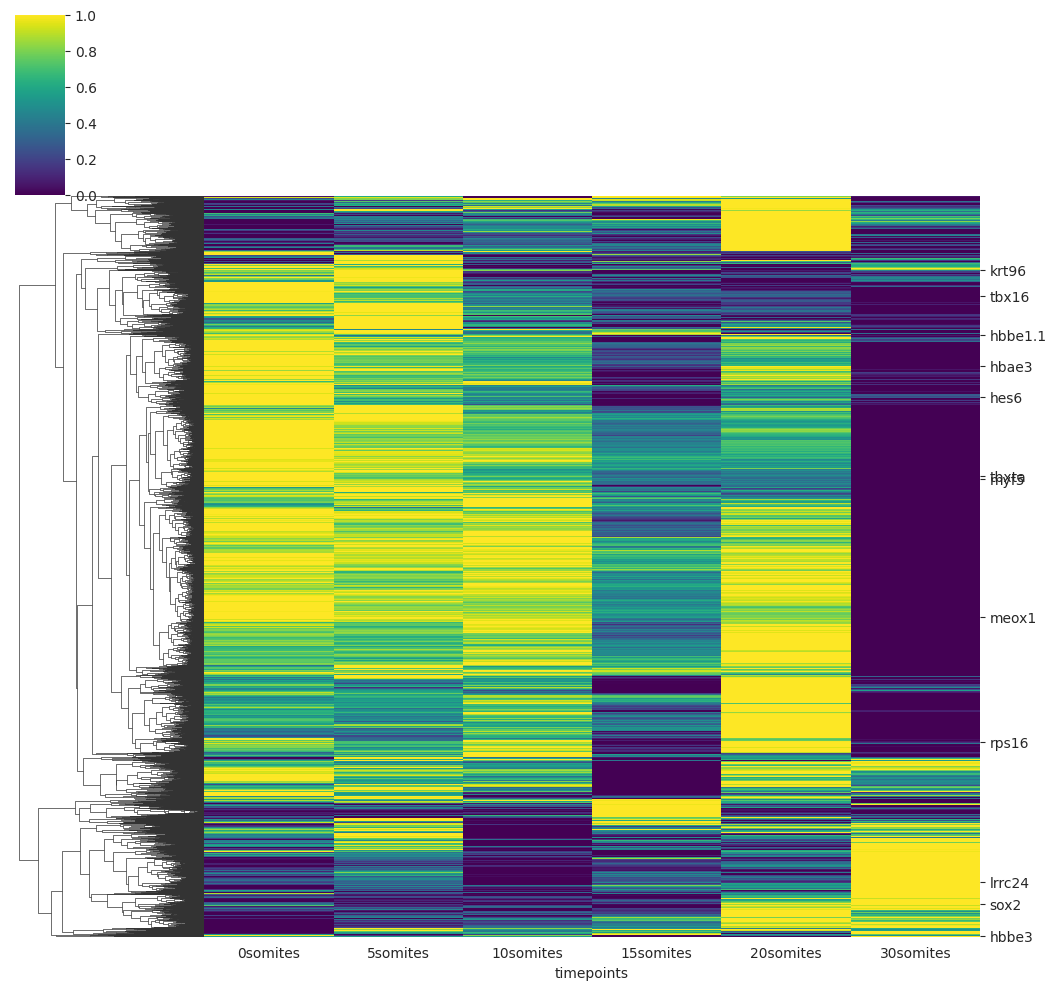

In [122]:
# Create a heatmap with hierarchical clustering
plt.figure(figsize=(12, 8))
g = sns.clustermap(normalized_timepoints_by_genes.T, method='average', metric='euclidean', cmap='viridis', standard_scale=0,
               row_cluster=True, col_cluster=False, yticklabels=False)

reordered_labels = normalized_timepoints_by_genes.T.index[g.dendrogram_row.reordered_ind].tolist()
use_labels = ["myf5","sox2","tbxta",
              "meox1","tbx16","hes6",
              "hbbe1.1","hbae3","hbbe3","rps16",
              "lrrc24","krt96"]
use_ticks = [reordered_labels.index(label) + .5 for label in use_labels]
g.ax_heatmap.set(yticks=use_ticks, yticklabels=use_labels)
g.savefig(figpath + "clustered_heatmap_gene_activity_score_timepoints_norm.png")
g.savefig(figpath + "clustered_heatmap_gene_activity_score_timepoints_norm.pdf")
plt.show()

## Step 4. correlation between ATAC and RNA

In [14]:
# Group by 'timepoint' and calculate the mean of each gene across cells within each timepoint
df_avg_RNA = pd.DataFrame(adata_RNA.to_df()).groupby(adata_RNA.obs["dev_stage"]).mean()

# Rename the index to indicate it's timepoint and columns to indicate genes
df_avg_RNA.index.name = 'timepoint'
print(df_avg_RNA)

/tmp/ipykernel_806025/3312619173.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_avg_RNA = pd.DataFrame(adata_RNA.to_df()).groupby(adata_RNA.obs["dev_stage"]).mean()


             ptpn12     phtf2   phtf2.1  CU856344.1  si:zfos-932h1.3  \
timepoint                                                              
0somites   0.004380  0.003705  0.003320    0.001046         0.003556   
5somites   0.004743  0.002856  0.004415    0.000512         0.003338   
10somites  0.003407  0.003258  0.007897    0.000528         0.006024   
15somites  0.007047  0.006020  0.015391    0.000928         0.007851   
20somites  0.002883  0.003371  0.007894    0.000151         0.003975   
30somites  0.001634  0.000957  0.003331    0.000442         0.002898   

             mansc1      lrp6    dusp16    crebl2     gpr19  ...    mt-nd4  \
timepoint                                                    ...             
0somites   0.000074  0.017872  0.030984  0.022127  0.080829  ...  1.920163   
5somites   0.000100  0.011550  0.025287  0.017725  0.026617  ...  2.538482   
10somites  0.000237  0.013377  0.035342  0.019646  0.018433  ...  2.624617   
15somites  0.000322  0.023251  0.

In [17]:
# copy over the "dev_stage" from RNA to ATAC object
adata_ATAC.obs["dev_stage"] = adata_ATAC.obs_names.map(adata_RNA.obs["dev_stage"])
adata_ATAC

AnnData object with n_obs × n_vars = 94562 × 25032
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'dev_stage'
    var: 'features'
    obsm: 'X_umap', 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'

In [18]:
# Group by 'timepoint' and calculate the mean of each gene activity across cells within each timepoint
df_avg_ATAC = pd.DataFrame(adata_ATAC.to_df()).groupby(adata_ATAC.obs["dev_stage"]).mean()

# Rename the index to indicate it's timepoint and columns to indicate genes
df_avg_ATAC.index.name = 'timepoint'
print(df_avg_ATAC)

/tmp/ipykernel_806025/4254947720.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_avg_ATAC = pd.DataFrame(adata_ATAC.to_df()).groupby(adata_ATAC.obs["dev_stage"]).mean()


             ptpn12     phtf2   phtf2.1  CU856344.1  si:zfos-932h1.3  \
timepoint                                                              
0somites   0.143865  0.238185  0.120311    0.323893         0.850621   
5somites   0.150622  0.216116  0.108529    0.311999         0.783701   
10somites  0.155376  0.199082  0.099138    0.272853         0.729104   
15somites  0.123227  0.178170  0.093875    0.237412         0.613412   
20somites  0.132475  0.219625  0.116590    0.261170         0.762197   
30somites  0.095610  0.139564  0.079889    0.182330         0.708044   

             mansc1      lrp6    dusp16    crebl2     gpr19  ...    mt-co2  \
timepoint                                                    ...             
0somites   0.080044  0.181891  0.535491  0.464024  0.709905  ...  2.975139   
5somites   0.081753  0.182372  0.463898  0.372787  0.421097  ...  3.387079   
10somites  0.067364  0.167795  0.423473  0.354107  0.361076  ...  2.933172   
15somites  0.067995  0.139068  0.

In [19]:
# Find intersection of genes between RNA and ATAC data
common_genes = df_avg_RNA.columns.intersection(df_avg_ATAC.columns)

# Subset both dataframes for common genes
df_RNA_common = df_avg_RNA[common_genes]
df_ATAC_common = df_avg_ATAC[common_genes]

In [20]:
# Create a new DataFrame to store correlation coefficients for each gene
correlation_df = pd.DataFrame(index=common_genes, columns=['correlation'])

# Compute Pearson correlation coefficient for each gene across timepoints
for gene in common_genes:
    correlation_df.loc[gene, 'correlation'] = df_RNA_common[gene].corr(df_ATAC_common[gene])

print(correlation_df)

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


                correlation
ptpn12             0.309749
phtf2              0.322524
phtf2.1            -0.17549
CU856344.1         0.320173
si:zfos-932h1.3   -0.725258
...                     ...
mt-nd4l           -0.522835
mt-nd4            -0.239912
mt-nd5            -0.636693
mt-nd6            -0.601655
mt-cyb            -0.229593

[25031 rows x 1 columns]


In [29]:
# Drop NaN values from correlation dataframe, if any
correlation_df = correlation_df.dropna()

# Determine the top 5% and bottom 5% thresholds
top_threshold = correlation_df['correlation'].quantile(0.95)
bottom_threshold = correlation_df['correlation'].quantile(0.05)

# Get the top 5% and bottom 5% of the correlation coefficients
top_5_percent = correlation_df[correlation_df['correlation'] >= top_threshold]
bottom_5_percent = correlation_df[correlation_df['correlation'] <= bottom_threshold]

# Display the results
print("Top 5% Correlations:")
print(top_5_percent)

print("\nBottom 5% Correlations:")
print(bottom_5_percent)

Top 5% Correlations:
                 correlation
gpr19               0.939197
msgn1                0.96776
si:ch211-152c2.3    0.944498
ripply2             0.920757
dnajc2              0.899219
...                      ...
ptprz1a             0.885123
ugt5a2              0.978075
FQ976913.1          0.876729
lamb1a              0.905092
tmem231             0.874829

[1223 rows x 1 columns]

Bottom 5% Correlations:
                   correlation
si:zfos-932h1.3      -0.725258
mansc1               -0.921655
nudt4b                -0.77682
glipr1a              -0.923932
zdhhc17              -0.760872
...                        ...
si:ch211-113a14.24   -0.811999
mafb                 -0.728857
si:dkey-234i14.6     -0.855131
ldlrad3              -0.768226
CABZ01095001.1       -0.779756

[1223 rows x 1 columns]


In [33]:
# Convert the index to a list and save as a text file
top_genes_list = top_genes.tolist()

# Save the gene names as a text file using to_csv
with open('top_5_percent_genes.txt', 'w') as f:
    for gene in top_genes_list:
        f.write(f"{gene}\n")

In [34]:
# Convert the index to a list and save as a text file

bottom_genes_list = bottom_5_percent.index.tolist()

# Save the gene names as a text file using to_csv
with open('bottom_5_percent_genes.txt', 'w') as f:
    for gene in bottom_genes_list:
        f.write(f"{gene}\n")

In [35]:
def generate_permutation_without_self_match(genes):
    """Generate a permutation of gene names such that no gene is paired with itself."""
    while True:
        permuted_genes = np.random.permutation(genes)
        # Check if any gene is paired with itself; if not, return
        if not np.any(permuted_genes == genes):
            return permuted_genes


# Generate a valid permutation without any gene being paired with itself
shuffled_columns = generate_permutation_without_self_match(common_genes)
df_ATAC_shuffled = df_ATAC_common[shuffled_columns]

# Create a DataFrame to store correlation coefficients for non-pairs
null_correlation_df = pd.DataFrame(index=common_genes, columns=['correlation'])

# Compute Pearson correlation coefficient for each "non-pair" gene
for gene_rna, gene_atac in zip(common_genes, shuffled_columns):
    null_correlation_df.loc[gene_rna, 'correlation'] = df_RNA_common[gene_rna].corr(df_ATAC_shuffled[gene_atac])

# Drop NaN values if any were generated
null_correlation_df = null_correlation_df.dropna()

print(null_correlation_df)

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


                correlation
ptpn12             0.016858
phtf2             -0.360469
phtf2.1           -0.630899
CU856344.1          0.14623
si:zfos-932h1.3    0.596033
...                     ...
mt-nd4l            0.587633
mt-nd4            -0.471608
mt-nd5             -0.18389
mt-nd6             0.705127
mt-cyb            -0.469833

[24407 rows x 1 columns]


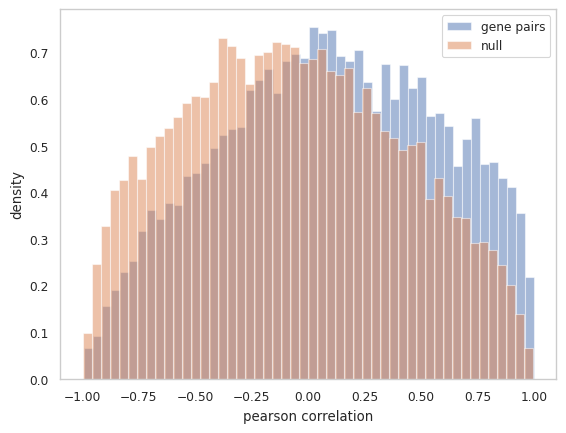

In [41]:
plt.hist(correlation_df.correlation, bins=50, density=True, alpha=0.5)
plt.hist(null_correlation_df.correlation, bins=50, density=True, alpha=0.5)
plt.legend(["gene pairs", "null"])
plt.xlabel("pearson correlation")
plt.ylabel("density")
plt.grid(False)
plt.savefig("pearson_corr_hist.pdf")
plt.show()

## highly variable genes (RNA expression level)

In [57]:
# Calculate highly variable genes in the RNA data
sc.pp.highly_variable_genes(adata_RNA, flavor='seurat', n_top_genes=2000)

# Subset the adata_RNA object to only include highly variable genes
adata_RNA_hvg = adata_RNA[:, adata_RNA.var['highly_variable']]

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]


In [58]:
# Group by 'timepoint' and calculate the mean of each gene across cells within each timepoint
df_avg_RNA = pd.DataFrame(adata_RNA_hvg.to_df()).groupby(adata_RNA_hvg.obs["dev_stage"]).mean()

# Rename the index to indicate it's timepoint and columns to indicate genes
df_avg_RNA.index.name = 'timepoint'
print(df_avg_RNA)

/tmp/ipykernel_806025/1026679821.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_avg_RNA = pd.DataFrame(adata_RNA_hvg.to_df()).groupby(adata_RNA_hvg.obs["dev_stage"]).mean()


              msgn1  si:ch211-152c2.3   ripply2    chrm2a   tbc1d30    rassf3  \
timepoint                                                                       
0somites   0.819822          2.373471  0.079323  0.002924  0.013762  0.035928   
5somites   0.695677          1.668468  0.057044  0.002949  0.010712  0.055337   
10somites  0.551664          0.718233  0.031635  0.004486  0.006408  0.101445   
15somites  0.476335          0.209906  0.028938  0.010626  0.006783  0.143578   
20somites  0.316059          0.114317  0.031582  0.004415  0.003686  0.075629   
30somites  0.031827          0.038603  0.007965  0.009564  0.001873  0.033713   

               tfec      elk3     wnt5b    scube1  ...  tnni2a.4     lsp1a  \
timepoint                                          ...                       
0somites   0.000781  0.042114  0.317626  0.041746  ...  0.001350  0.437691   
5somites   0.001059  0.041644  0.249139  0.025923  ...  0.000957  0.494614   
10somites  0.010749  0.077765  0.247104

In [17]:
# copy over the "dev_stage" from RNA to ATAC object
adata_ATAC.obs["dev_stage"] = adata_ATAC.obs_names.map(adata_RNA.obs["dev_stage"])
adata_ATAC

AnnData object with n_obs × n_vars = 94562 × 25032
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'dev_stage'
    var: 'features'
    obsm: 'X_umap', 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'

In [18]:
# Group by 'timepoint' and calculate the mean of each gene activity across cells within each timepoint
df_avg_ATAC = pd.DataFrame(adata_ATAC.to_df()).groupby(adata_ATAC.obs["dev_stage"]).mean()

# Rename the index to indicate it's timepoint and columns to indicate genes
df_avg_ATAC.index.name = 'timepoint'
print(df_avg_ATAC)

/tmp/ipykernel_806025/4254947720.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_avg_ATAC = pd.DataFrame(adata_ATAC.to_df()).groupby(adata_ATAC.obs["dev_stage"]).mean()


             ptpn12     phtf2   phtf2.1  CU856344.1  si:zfos-932h1.3  \
timepoint                                                              
0somites   0.143865  0.238185  0.120311    0.323893         0.850621   
5somites   0.150622  0.216116  0.108529    0.311999         0.783701   
10somites  0.155376  0.199082  0.099138    0.272853         0.729104   
15somites  0.123227  0.178170  0.093875    0.237412         0.613412   
20somites  0.132475  0.219625  0.116590    0.261170         0.762197   
30somites  0.095610  0.139564  0.079889    0.182330         0.708044   

             mansc1      lrp6    dusp16    crebl2     gpr19  ...    mt-co2  \
timepoint                                                    ...             
0somites   0.080044  0.181891  0.535491  0.464024  0.709905  ...  2.975139   
5somites   0.081753  0.182372  0.463898  0.372787  0.421097  ...  3.387079   
10somites  0.067364  0.167795  0.423473  0.354107  0.361076  ...  2.933172   
15somites  0.067995  0.139068  0.

In [59]:
# Find intersection of genes between RNA and ATAC data
common_genes = df_avg_RNA.columns.intersection(df_avg_ATAC.columns)

# Subset both dataframes for common genes
df_RNA_common = df_avg_RNA[common_genes]
df_ATAC_common = df_avg_ATAC[common_genes]

In [60]:
# Create a new DataFrame to store correlation coefficients for each gene
correlation_df = pd.DataFrame(index=common_genes, columns=['correlation'])

# Compute Pearson correlation coefficient for each gene across timepoints
for gene in common_genes:
    correlation_df.loc[gene, 'correlation'] = df_RNA_common[gene].corr(df_ATAC_common[gene])

print(correlation_df)

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


                 correlation
msgn1                0.96776
si:ch211-152c2.3    0.944498
ripply2             0.920757
chrm2a               0.00653
tbc1d30             0.349544
...                      ...
trpm1b              0.623381
flnca                0.03171
mt-nd1             -0.317624
mt-co1             -0.298954
mt-atp6            -0.469406

[1797 rows x 1 columns]


/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/numpy/lib/histograms.py:825: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/numpy/lib/histograms.py:826: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


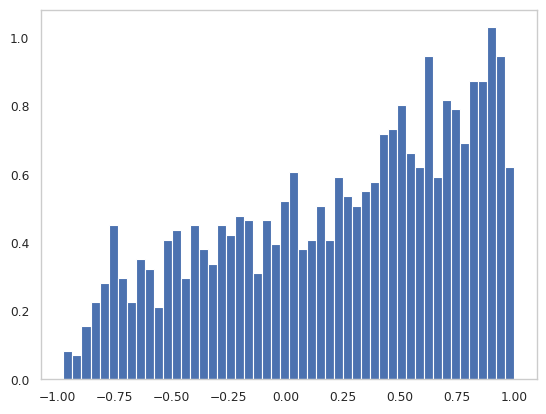

In [61]:
plt.hist(correlation_df.correlation, bins=50, density=True)
plt.grid(False)
plt.show()

In [67]:
# def generate_permutation_without_self_match(genes):
#     """Generate a permutation of gene names such that no gene is paired with itself."""
#     while True:
#         permuted_genes = np.random.permutation(genes)
#         # Check if any gene is paired with itself; if not, return
#         if not np.any(permuted_genes == genes):
#             return permuted_genes


# # Generate a valid permutation without any gene being paired with itself
# shuffled_columns = generate_permutation_without_self_match(common_genes)
# df_ATAC_shuffled = df_ATAC_common[shuffled_columns]

# # Create a DataFrame to store correlation coefficients for non-pairs
# null_correlation_df = pd.DataFrame(index=common_genes, columns=['correlation'])

# # Compute Pearson correlation coefficient for each "non-pair" gene
# for gene_rna, gene_atac in zip(common_genes, shuffled_columns):
#     null_correlation_df.loc[gene_rna, 'correlation'] = df_RNA_common[gene_rna].corr(df_ATAC_shuffled[gene_atac])

# # Drop NaN values if any were generated
# null_correlation_df = null_correlation_df.dropna()

# print(null_correlation_df)

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


                 correlation
msgn1              -0.946029
si:ch211-152c2.3    0.929954
ripply2            -0.433501
chrm2a             -0.851109
tbc1d30             0.519856
...                      ...
trpm1b              0.361488
flnca               0.208954
mt-nd1             -0.391848
mt-co1              0.280777
mt-atp6             0.546041

[1794 rows x 1 columns]


In [73]:
import itertools
import pandas as pd

# Generate all possible non-pair combinations using itertools.product
all_pairs = list(itertools.product(common_genes, common_genes))

# Filter out self-pairs (gene_rna == gene_atac)
non_pairs = [(gene_rna, gene_atac) for gene_rna, gene_atac in all_pairs if gene_rna != gene_atac]

# # Create a DataFrame to store correlation coefficients for non-pairs
# null_correlation_df = pd.DataFrame(columns=['gene_rna', 'gene_atac', 'correlation'])

# # Compute Pearson correlation coefficient for each "non-pair" gene
# for gene_rna, gene_atac in non_pairs:
#     correlation = df_RNA_common[gene_rna].corr(df_ATAC_common[gene_atac])
#     null_correlation_df = null_correlation_df.append({
#         'gene_rna': gene_rna,
#         'gene_atac': gene_atac,
#         'correlation': correlation
#     }, ignore_index=True)

# # Drop NaN values if any were generated
# null_correlation_df = null_correlation_df.dropna()

# print(null_correlation_df)
# Create a list to collect correlation results
correlation_results = []

# Compute Pearson correlation coefficient for each "non-pair" gene
for gene_rna, gene_atac in non_pairs:
    correlation = df_RNA_common[gene_rna].corr(df_ATAC_common[gene_atac])
    correlation_results.append({
        'gene_rna': gene_rna,
        'gene_atac': gene_atac,
        'correlation': correlation
    })

# Convert the results list to a DataFrame
null_correlation_df = pd.DataFrame(correlation_results)

# Drop NaN values if any were generated
null_correlation_df = null_correlation_df.dropna()

print(null_correlation_df)

In [83]:
# Function to generate a permutation of gene names such that no gene is paired with itself
def generate_permutation_without_self_match(genes):
    """Generate a permutation of gene names such that no gene is paired with itself."""
    while True:
        permuted_genes = np.random.permutation(genes)
        # Check if any gene is paired with itself; if not, return
        if not np.any(permuted_genes == genes):
            return permuted_genes

# Number of repetitions
n_repeats = 5

# Create a DataFrame to accumulate correlation values for each gene across repetitions
correlation_accumulator = pd.DataFrame(index=common_genes, columns=range(n_repeats), dtype=float)

# Repeat the permutation and correlation calculation multiple times
for i in range(n_repeats):
    # Generate a valid permutation without any gene being paired with itself
    shuffled_columns = generate_permutation_without_self_match(common_genes)
    df_ATAC_shuffled = df_ATAC_common[shuffled_columns]

    # Compute Pearson correlation coefficient for each "non-pair" gene
    for gene_rna, gene_atac in zip(common_genes, shuffled_columns):
        correlation_accumulator.loc[gene_rna, i] = df_RNA_common[gene_rna].corr(df_ATAC_shuffled[gene_atac])

# Compute the average correlation per gene across repetitions
average_correlation_df = correlation_accumulator.mean(axis=1)

# Drop NaN values if any were generated
average_correlation_df = average_correlation_df.dropna()

# Convert to a DataFrame for better formatting if needed
null_correlation_df = pd.DataFrame(average_correlation_df, columns=['average_correlation'])

print(null_correlation_df)

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/hpc/user_apps/data.science/conda_e

                  average_correlation
msgn1                        0.117731
si:ch211-152c2.3             0.199088
ripply2                      0.088619
chrm2a                      -0.256571
tbc1d30                      0.270417
...                               ...
trpm1b                       0.073724
flnca                        0.068706
mt-nd1                      -0.271602
mt-co1                       0.234149
mt-atp6                      0.099380

[1797 rows x 1 columns]


In [84]:
null_correlation_df.average_correlation.mean()

-0.07519659864765985

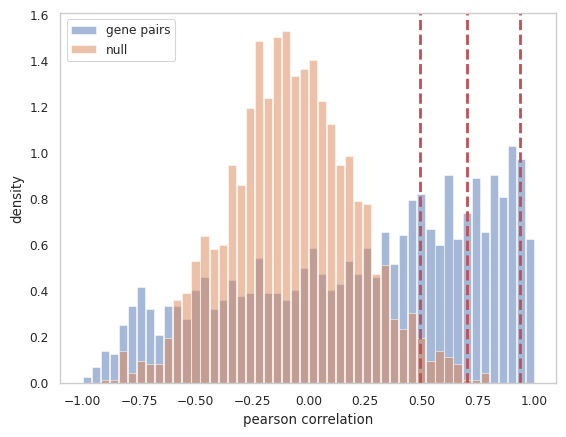

In [105]:
plt.hist(correlation_df.correlation, bins=50, density=True, alpha=0.5, range=(-1, 1), rwidth=0.9)
plt.hist(null_correlation_df.average_correlation, bins=50, density=True, alpha=0.5, range=(-1, 1), rwidth=0.9)

plt.legend(["gene pairs", "null"])
# Draw vertical lines for the cutoffs
plt.axvline(x=top_threshold, color='r', linestyle='--', linewidth=2, label='Top 5% cutoff')
plt.axvline(x=mid_threshold, color='r', linestyle='--', linewidth=2, label='Top 75% cutoff')
plt.axvline(x=bottom_threshold, color='r', linestyle='--', linewidth=2, label='Top 50% cutoff')
plt.xlabel("pearson correlation")
plt.ylabel("density")
plt.grid(False)
plt.savefig("pearson_corr_hist_hvgs.pdf")
plt.show()

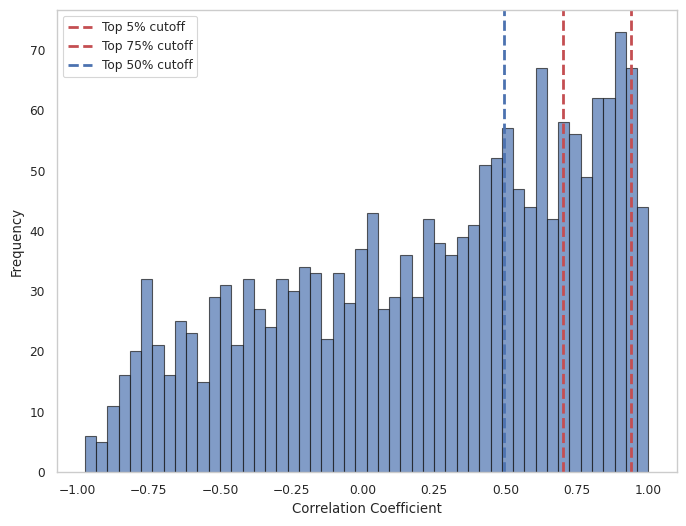

In [100]:
# Calculate the thresholds for the top 5% and bottom 5% correlations
top_threshold = correlation_df['correlation'].quantile(0.95)
mid_threshold = correlation_df['correlation'].quantile(0.75)
bottom_threshold = correlation_df['correlation'].quantile(0.60)

# Plot the histogram of correlation coefficients
plt.figure(figsize=(8, 6))
plt.hist(correlation_df['correlation'], bins=50, edgecolor='k', alpha=0.7)

# Draw vertical lines for the cutoffs
plt.axvline(x=top_threshold, color='r', linestyle='--', linewidth=2, label='Top 5% cutoff')
plt.axvline(x=mid_threshold, color='r', linestyle='--', linewidth=2, label='Top 75% cutoff')
plt.axvline(x=bottom_threshold, color='b', linestyle='--', linewidth=2, label='Top 50% cutoff')

# Add labels and legend
plt.xlabel('Correlation Coefficient')
plt.ylabel('Frequency')
plt.legend()
plt.grid(False)
plt.show()

In [97]:
# Drop NaN values from correlation dataframe, if any
correlation_df = correlation_df.dropna()

# Determine the top 5% and bottom 5% thresholds
top_threshold = correlation_df['correlation'].quantile(0.95)
mid_threshold = correlation_df['correlation'].quantile(0.75)
bottom_threshold = correlation_df['correlation'].quantile(0.50)

# Get the top 5% and bottom 5% of the correlation coefficients
top_5_percent = correlation_df[correlation_df['correlation'] >= top_threshold]
# Get the middle 50-75% of the correlation coefficients
mid_50_75_percent = correlation_df[(correlation_df['correlation'] <= mid_threshold) & (correlation_df['correlation'] >= bottom_threshold)]

# Display the results
print("Top 5% Correlations:")
print(top_5_percent)

print("\nTop 50-75% Correlations:")
print(mid_50_75_percent)

Top 5% Correlations:
                 correlation
msgn1                0.96776
si:ch211-152c2.3    0.944498
myf5                 0.99755
hist1h2a6           0.999963
hist1h4l.6          0.999998
...                      ...
ved                 0.983391
vim                 0.955251
szl                 0.978176
mespab              0.949445
ntrk3a              0.950534

[90 rows x 1 columns]

Top 50-75% Correlations:
        correlation
tbc1d30    0.349544
tfec       0.463546
pcloa      0.475854
btbd11a    0.350781
lmo3       0.592226
...             ...
wt1a       0.399295
stra6      0.613811
abtb2b     0.638798
myod1      0.559184
trpm1b     0.623381

[448 rows x 1 columns]


In [101]:
# Convert the index to a list and save as a text file
top_genes_list = top_5_percent.index.tolist()

# Save the gene names as a text file using to_csv
with open('top_5_percent_genes.txt', 'w') as f:
    for gene in top_genes_list:
        f.write(f"{gene}\n")

In [102]:
# Convert the index to a list and save as a text file
mid_50_75_genes_list = mid_50_75_percent.index.tolist()

# Save the gene names as a text file using to_csv
with open('mid_50_75_genes_list.txt', 'w') as f:
    for gene in mid_50_75_genes_list:
        f.write(f"{gene}\n")

In [119]:
correlation_df.correlation.mean()

0.23933751013830035